In [230]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any, Callable, Mapping, Optional, Text, Tuple, Union, Iterable
import numpy as np
import plotly.graph_objects as go
from absl import logging
import hydra
import matplotlib.patches as mpatches

sns.set_theme()


In [231]:
import wandb
from dm_env import specs
import uuid
from collections import OrderedDict

from helpers import modulators

In [232]:
from hydra.core.global_hydra import GlobalHydra
from omegaconf import DictConfig, OmegaConf

# Clear existing Hydra instance if already initialized
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Initialize Hydra and load the config directly
hydra.initialize(config_path="../", version_base=None)
cfg = hydra.compose(config_name="full_train_miniworld_slippery_fix")

In [233]:
if cfg.logging.mode == "full_train":
    experiment = cfg.domain.train.logging.experiment

elif cfg.logging.mode == "test":
    experiment = cfg.domain.test.logging.experiment

elif cfg.logging.mode == "pretrain":
    experiment = cfg.domain.pretrain.logging.experiment
elif cfg.logging.mode == "full_train_slippery":
    experiment = cfg.domain.train.logging.experiment + "_slippery"

elif cfg.logging.mode == "full_train_slippery_fix":
    experiment = cfg.domain.train.logging.experiment + "_slippery_fix"

else:
    raise ValueError("Invalid logging mode: {}".format(cfg.logging.mode))

In [234]:
moving_average_window = 10 # window size for moving average

In [235]:
api = wandb.Api()

project_name = "continual_rl" + "_" + cfg.logging.mode + "_" + experiment
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

summary_list, config_list, name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

num_of_runs: 91


In [236]:
for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "best" not in run.tags:
        continue

    if run.config["agent_feature_dim"] != 256:
        continue

    print(run.config["agent_name"])

    avg_episode_returns_history = run.scan_history(keys=["eval/avg_episode_returns"])
    avg_episode_return = [
        row["eval/avg_episode_returns"] for row in avg_episode_returns_history
    ]

    avg_episode_length_history = run.scan_history(keys=["eval/avg_episode_length"])
    avg_episode_length = [
        row["eval/avg_episode_length"] for row in avg_episode_length_history
    ]

    steps_history = run.scan_history(keys=["eval/steps"])

    steps = [row["eval/steps"] for row in steps_history]

    task_history = run.scan_history(keys=["train/task"])
    task = [row["train/task"] for row in task_history]


    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue

    print("len(steps): ", len(steps))
    print("len(avg_episode_return): ", len(avg_episode_return))
    print("len(avg_episode_length): ", len(avg_episode_length))

    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp = dict()
    temp["eval/steps"] = steps
    temp["eval/episode_return"] = avg_episode_return
    temp["eval/avg_episode_length"] = avg_episode_length
    temp["train/task"] = task

    temp["eval/mvg_avg_episode_length"] = np.convolve(
        temp["eval/avg_episode_length"],
        np.ones((moving_average_window,))
        / moving_average_window,
        mode="valid",
    )

    temp["eval/mvg_avg_episode_length"] = np.pad(
        temp["eval/mvg_avg_episode_length"],
        (moving_average_window - 1, 0),
        "constant",
        constant_values=cfg.domain.max_episode_length,
    )

    if "attention" in run.config["agent_name"]:
        #attention 1
        attention_8_history_1 = run.scan_history(keys=["train/attention_outputs_u8_mean"])
        attention_8_1 = [row["train/attention_outputs_u8_mean"] for row in attention_8_history_1]

        attention_7_history_1 = run.scan_history(keys=["train/attention_outputs_u7_mean"])
        attention_7_1 = [row["train/attention_outputs_u7_mean"] for row in attention_7_history_1]

        attention_6_history_1 = run.scan_history(keys=["train/attention_outputs_u6_mean"])
        attention_6_1 = [row["train/attention_outputs_u6_mean"] for row in attention_6_history_1]

        attention_5_history_1 = run.scan_history(keys=["train/attention_outputs_u5_mean"])
        attention_5_1 = [row["train/attention_outputs_u5_mean"] for row in attention_5_history_1]

        attention_4_history_1 = run.scan_history(keys=["train/attention_outputs_u4_mean"])
        attention_4_1 = [row["train/attention_outputs_u4_mean"] for row in attention_4_history_1]

        attention_3_history_1 = run.scan_history(keys=["train/attention_outputs_u3_mean"])
        attention_3_1 = [row["train/attention_outputs_u3_mean"] for row in attention_3_history_1]

        attention_2_history_1 = run.scan_history(keys=["train/attention_outputs_u2_mean"])
        attention_2_1 = [row["train/attention_outputs_u2_mean"] for row in attention_2_history_1]

        attention_1_history_1 = run.scan_history(keys=["train/attention_outputs_u1_mean"])
        attention_1_1 = [row["train/attention_outputs_u1_mean"] for row in attention_1_history_1]

        attention_0_history_1 = run.scan_history(keys=["train/attention_outputs_u0_mean"])
        attention_0_1 = [row["train/attention_outputs_u0_mean"] for row in attention_0_history_1]

        # attention_8_1.insert(0, 0)
        # attention_7_1.insert(0, 0)
        # attention_6_1.insert(0, 0)
        # attention_5_1.insert(0, 0)
        # attention_4_1.insert(0, 0)
        # attention_3_1.insert(0, 0)
        # attention_2_1.insert(0, 0)
        # attention_1_1.insert(0, 0)
        # attention_0_1.insert(0, 0)

        temp["train/attention_outputs_u8_mean"] = attention_8_1
        temp["train/attention_outputs_u7_mean"] = attention_7_1
        temp["train/attention_outputs_u6_mean"] = attention_6_1
        temp["train/attention_outputs_u5_mean"] = attention_5_1
        temp["train/attention_outputs_u4_mean"] = attention_4_1
        temp["train/attention_outputs_u3_mean"] = attention_3_1
        temp["train/attention_outputs_u2_mean"] = attention_2_1
        temp["train/attention_outputs_u1_mean"] = attention_1_1
        temp["train/attention_outputs_u0_mean"] = attention_0_1


    else:
        zeros_list = [0] * len(steps)
        temp["train/attention_outputs_u8_mean"] = zeros_list
        temp["train/attention_outputs_u7_mean"] = zeros_list
        temp["train/attention_outputs_u6_mean"] = zeros_list
        temp["train/attention_outputs_u5_mean"] = zeros_list
        temp["train/attention_outputs_u4_mean"] = zeros_list
        temp["train/attention_outputs_u3_mean"] = zeros_list
        temp["train/attention_outputs_u2_mean"] = zeros_list
        temp["train/attention_outputs_u1_mean"] = zeros_list
        temp["train/attention_outputs_u0_mean"] = zeros_list

    print("len attention_0_1: ", len(temp["train/attention_outputs_u0_mean"]))
    print("len attention_1_1: ", len(temp["train/attention_outputs_u1_mean"]))
    print("len attention_2_1: ", len(temp["train/attention_outputs_u2_mean"]))
    print("len attention_3_1: ", len(temp["train/attention_outputs_u3_mean"]))
    print("len attention_4_1: ", len(temp["train/attention_outputs_u4_mean"]))
    print("len attention_5_1: ", len(temp["train/attention_outputs_u5_mean"]))
    print("len attention_6_1: ", len(temp["train/attention_outputs_u6_mean"]))
    print("len attention_7_1: ", len(temp["train/attention_outputs_u7_mean"]))
    print("len attention_8_1: ", len(temp["train/attention_outputs_u8_mean"]))


    summary_list.append(temp)
    del temp

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    name_list.append(run.name)

idx: 0
simple_sf_agent
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
len attention_0_1:  200
len attention_1_1:  200
len attention_2_1:  200
len attention_3_1:  200
len attention_4_1:  200
len attention_5_1:  200
len attention_6_1:  200
len attention_7_1:  200
len attention_8_1:  200
simple_sf_agent
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
len attention_0_1:  200
len attention_1_1:  200
len attention_2_1:  200
len attention_3_1:  200
len attention_4_1:  200
len attention_5_1:  200
len attention_6_1:  200
len attention_7_1:  200
len attention_8_1:  200
simple_sf_agent
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
len attention_0_1:  200
len attention_1_1:  200
len attention_2_1:  200
len attention_3_1:  200
len attention_4_1:  200
len attention_5_1:  200
len attention_6_1:  200
len attention_7_1:  200
len attention_8_1:  200
simple_sf_agent
len(steps):  200
len(avg_episode_return):  200
len

In [237]:
runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

# create a new column using agent_name
runs_df["agent_name"] = runs_df["config"].apply(lambda x: x["agent_name"])

# # create a new column using agents_seed
runs_df["agent_seed"] = runs_df["config"].apply(lambda x: x["agent_seed"])

In [238]:
agents_new_names = {
    "dqn": "DQN",
    "DQN_consolidation_params_continuous": "DQN + SC",
    "simple_sf_agent": "SF",
    "sf_consolidation_params_continuous": "SF + SC (Ours)",
    "dqn_online_ewc": "DQN + EWC",
    "simple_sf_online_ewc": "SF + EWC",
    "sf_consolidation_params_continuous_softmax_attention_diff_unique": "SF + SC + Attention (Ours)",
    "DQN_plasticity_injection" : "DQN + P-last",
    "dqn_cbp" : "DQN + CBP",
}

In [239]:
# replace all "ddpg" in agent_name column with "DDPG"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "dqn", agents_new_names["dqn"]
)

In [240]:
# replace all "ddpg" in agent_name column with "DDPG"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "dqn_cbp", agents_new_names["dqn_cbp"]
)

In [241]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "simple_sf_agent", agents_new_names["simple_sf_agent"]
)

In [242]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "DQN_consolidation_params_continuous", agents_new_names["DQN_consolidation_params_continuous"]
)

In [243]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_consolidation_params_continuous", agents_new_names["sf_consolidation_params_continuous"]
)

In [244]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "dqn_online_ewc", agents_new_names["dqn_online_ewc"]
)

In [245]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "simple_sf_online_ewc", agents_new_names["simple_sf_online_ewc"]
)

In [246]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_consolidation_params_continuous_softmax_attention_diff_unique", agents_new_names["sf_consolidation_params_continuous_softmax_attention_diff_unique"]
)

In [247]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "DQN_plasticity_injection", agents_new_names["DQN_plasticity_injection"]
)

In [248]:
# print unique agent_name
print(runs_df["agent_name"].unique())

['SF' 'DQN' 'DQN + SC' 'SF + SC (Ours)' 'SF + SC + Attention (Ours)'
 'DQN + P-last' 'DQN + EWC' 'SF + EWC' 'DQN + CBP']


In [249]:
# remove the name and config column
runs_df = runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
runs_df = pd.concat(
    [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
)

In [250]:
def seq_len(x):
    if x is None:
        return 0
    if isinstance(x, (str, bytes)):
        return np.nan
    try:
        return len(x)
    except Exception:
        return np.nan

# Columns that look list/array-like
candidate_cols = [
    c for c in runs_df.columns
    if runs_df[c].apply(lambda x: isinstance(x, (list, tuple, np.ndarray, pd.Series))).any()
]

for c in candidate_cols:
    L = runs_df[c].apply(seq_len)
    bad = L[L != L.mode().iloc[0]]  # indices whose length ≠ most common length
    print(f"\nColumn: {c}")
    print("  common length:", L.mode().iloc[0])
    print("  unique lengths:", sorted(L.dropna().unique()))
    if not bad.empty:
        print("  offending rows:", bad.index.tolist())


Column: eval/steps
  common length: 200
  unique lengths: [np.int64(200)]

Column: eval/episode_return
  common length: 200
  unique lengths: [np.int64(200)]

Column: eval/avg_episode_length
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/task
  common length: 200
  unique lengths: [np.int64(200)]

Column: eval/mvg_avg_episode_length
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u8_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u7_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u6_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u5_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u4_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u3_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: t

In [251]:
# # remove the name and config column
# runs_df = runs_df.drop(columns=["name", "config"])
#
# # turn each key and its value into a column
# runs_df = pd.concat(
#     [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
# )

# runs_df = runs_df.drop(columns=["agent_seed"])

# reset index
runs_df = runs_df.reset_index(drop=True)

print(runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
runs_df = runs_df.explode(list(runs_df.columns[2:])).reset_index(drop=True)

# apply rolling mean to the column train/episode_reward
# runs_df["train/episode_reward"] = runs_df["train/episode_reward"].rolling(
#     window=cfg.plotting.moving_average_window, min_periods=1
# ).mean()

print(runs_df.shape)

print("dataframe: ", runs_df)

                    agent_name  agent_seed  \
0                           SF          97   
1                           SF         485   
2                           SF         388   
3                           SF         194   
4                           SF         679   
5                          DQN         485   
6                          DQN         388   
7                          DQN          97   
8                          DQN         291   
9                          DQN         582   
10                    DQN + SC          97   
11                    DQN + SC         485   
12                    DQN + SC         388   
13                    DQN + SC         194   
14                    DQN + SC         291   
15              SF + SC (Ours)         388   
16              SF + SC (Ours)         485   
17              SF + SC (Ours)          97   
18              SF + SC (Ours)         582   
19              SF + SC (Ours)         291   
20  SF + SC + Attention (Ours)    

In [252]:
color_code = {
    "DQN": "#1f77b4",
    "SF": "#ff7f0e",
    "DQN + SC": "#2ca02c",
    "SF + SC": "#9467bd",
    "SF + SC (Ours)": "#9467bd",
    "DQN + Plasticity": "#ffbb00",
    "DQN + P-last": "#ffbb00",
    # "DDPG + Plasticity (last few layers)": "#ffbb00",
    "SF + SC + Attention": "#8B4513",
    "SF + SC + Attention (Ours)": "#8B4513",
    "DQN\n +SC": "#2ca02c",
    "SF\n +SC": "#9467bd",
    "SF\n +SC (Ours)": "#9467bd",
    "SF\n +SC\n +Attention": "#8B4513",
    "SF\n +SC\n +Attention (Ours)": "#8B4513",
    "SF + EWC": "#e377c2",
    "DQN + EWC": "#bcbd22",
    "SF\n +EWC": "#e377c2",
    "DQN\n +EWC": "#bcbd22",
    "DQN + CBP": "#d62728",
    "DQN\n +CBP": "#d62728",
    # "SF + SC": "#ff7f0e",
    # "DDPG + SC": "#2ca02c",
    # "SF + SC": "#d62728",
    # "SF + Random": "#2ca02c",
    # "SF + Reconstruction": "#d62728",
    # "SF + Laplacian": "#9467bd",
    # "APS (Pre-train)": "#8c564b",
    # "Canonical-SF": "#e377c2",
    # "SF + Q-TD + Reward": "#bcbd22",
    # "SF simple + SC": "#2ca02c",
    # "SF simple + Task SC": "#d62728",
    # "SF simple + SC & Task SC": "#9467bd",
    # "DQN + SC": "#8c564b",
}

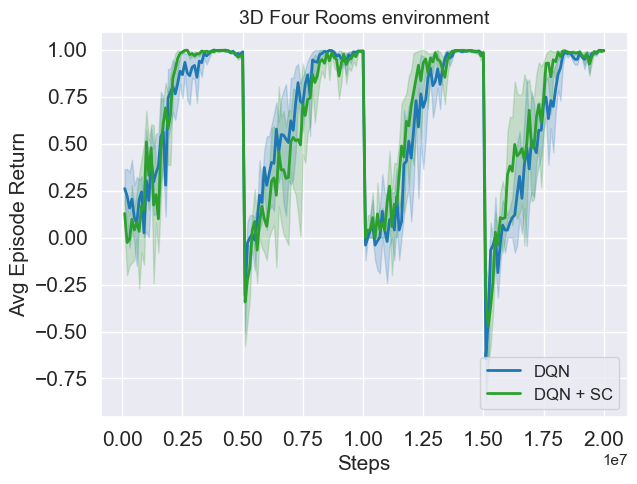

In [253]:
"""
This plot is to show how adding consolidation to Q-values are not very effective
"""

f, ax = plt.subplots(figsize=(6.8, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

plt.title("3D Four Rooms environment", fontsize=14)
plt.xlabel("Steps", fontsize=15)
plt.ylabel("Avg Episode Return", fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
filename = "avg_episode_returns_training_plot_fourrooms_slippery" + "_consolidating_only_qvalues"
plt.savefig(filename + ".pdf")
plt.show()

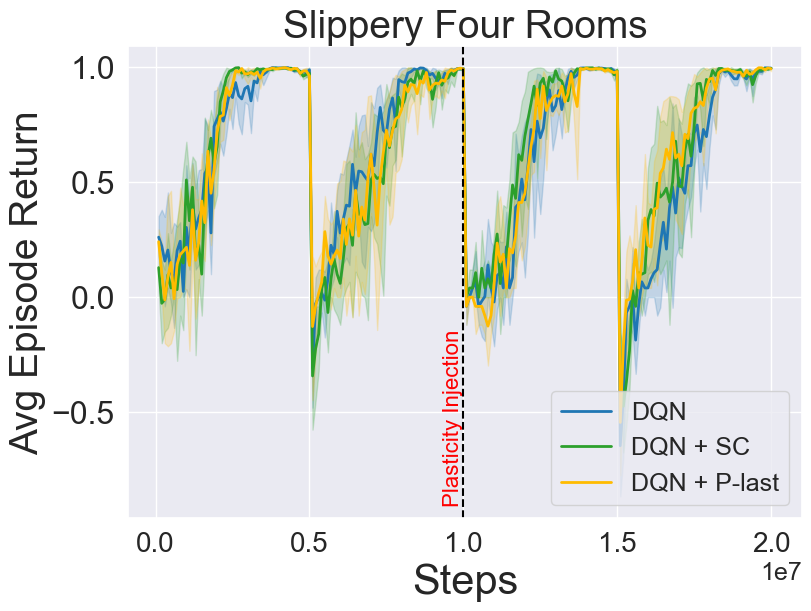

In [254]:
"""
This plot is to show how compare injecting plasticity vs consolidation to Q-values
"""

from matplotlib.ticker import MaxNLocator

f, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_plasticity_injection"]],
    label=agents_new_names["DQN_plasticity_injection"],
    color=color_code[agents_new_names["DQN_plasticity_injection"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

xline = 1e7
ymin, ymax = ax.get_ylim()

# draw the vertical line
plt.axvline(x=xline, color="black", linestyle="--", linewidth=1.5)

# add the text
plt.text(
    xline,                      # x position (same as line)
    ymin + 0.4 * (ymax - ymin), # 40% above the bottom
    "Plasticity Injection",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=16
)

plt.title("Slippery Four Rooms", fontsize=28)
plt.xlabel("Steps", fontsize=30)
plt.ylabel("Avg Episode Return", fontsize=28)
plt.legend(loc="lower right", fontsize=18)
plt.xticks(fontsize=20)
plt.yticks(fontsize=23)
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # ~5 ticks
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.gca().xaxis.get_offset_text().set_fontsize(18)
filename = "avg_episode_returns_training_plot_slippery_four_rooms" + "_plasticity_injection_vs_consolidation_q_values"
plt.savefig(filename + ".pdf")
plt.show()

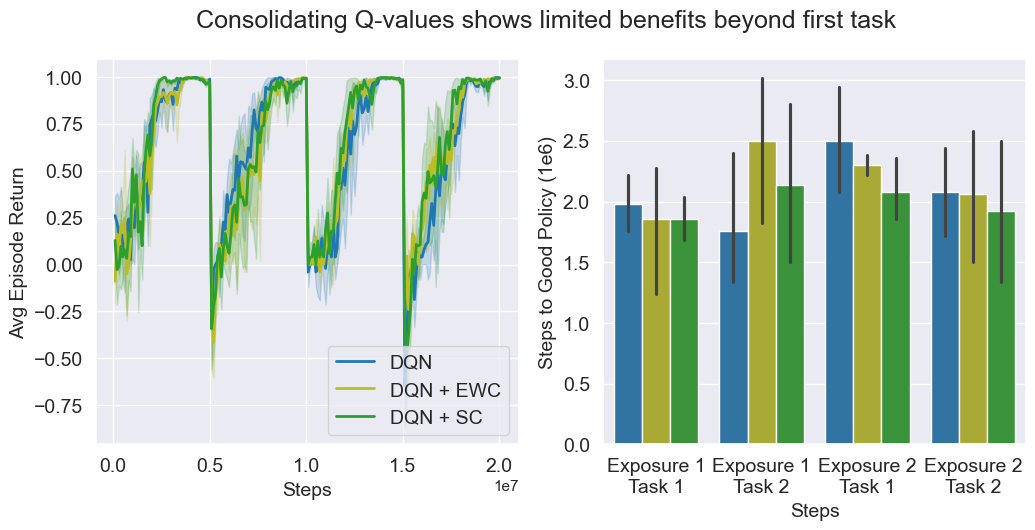

<Figure size 1400x1000 with 0 Axes>

In [255]:
"""
This plot is to compare the various consolidation techniques on Q-values
"""


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)


sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN",
    "DQN + EWC",
    "DQN + SC",
]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

# === Plotting ===
plt.figure(figsize=(14, 10))
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

fig.suptitle("Consolidating Q-values shows limited benefits beyond first task", fontsize=18)

axes[0].set_xlabel("Steps", fontsize=14)
axes[0].set_ylabel("Avg Episode Return", fontsize=14)
axes[0].tick_params(axis="x", labelsize=14)
axes[0].tick_params(axis="y", labelsize=14)
axes[0].legend(loc="lower right", fontsize=14)

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("Steps", fontsize=14)
axes[1].set_ylabel("Steps to Good Policy (1e6)", fontsize=14)
axes[1].tick_params(axis="x", labelsize=14)
axes[1].tick_params(axis="y", labelsize=14)
axes[1].legend_.remove()

filename = "consolidating_q_values_only_analysis_fourrooms_slippery"
plt.savefig(filename + ".pdf")
plt.tight_layout()
plt.show()

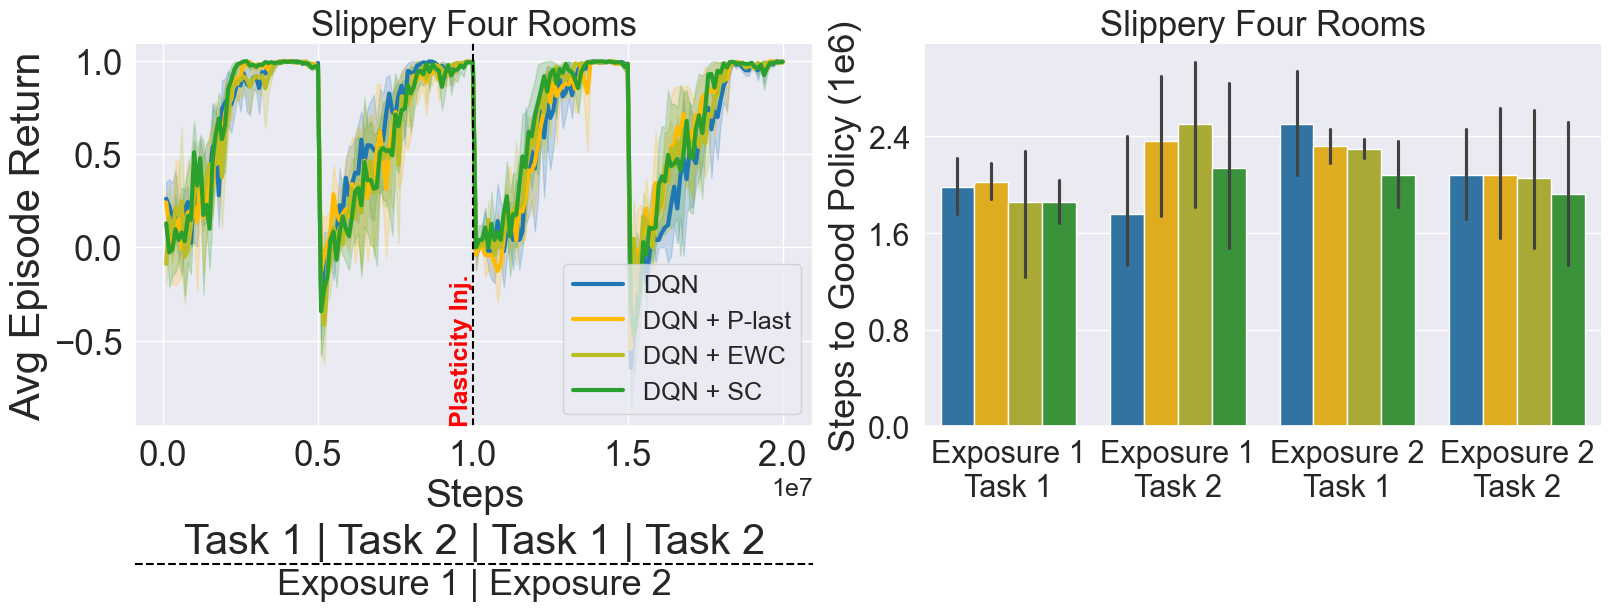

In [256]:
"""
This plot is to compare the plasticity injection vs consolidation on the Q-values
"""


fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_plasticity_injection"]],
    label=agents_new_names["DQN_plasticity_injection"],
    color=color_code[agents_new_names["DQN_plasticity_injection"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000
xline = 1e7

agent_order = [
    "DQN",
    "DQN + P-last",
    "DQN + EWC",
    "DQN + SC",
]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

# === Plotting ===
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

# fig.suptitle("Slippery Four Rooms: Plasticity-Stability Analysis", fontsize=30)

ymin, ymax = axes[0].get_ylim()

axes[0].set_title("Slippery Four Rooms", fontsize=25)
axes[0].set_xlabel("Steps", fontsize=28)
axes[0].set_ylabel("Avg Episode Return", fontsize=30)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].legend(loc="lower right", fontsize=18)
axes[0].axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
axes[0].text(
    xline,                      # x position (same as line)
    ymin + 0.4 * (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj.",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18,
    fontweight="bold"
)
axes[0].xaxis.get_offset_text().set_fontsize(18)

# axes[0].text(-0.1, 1.10, "(a)", transform=axes[0].transAxes,
#              fontsize=25, fontweight="bold", va="top", ha="right")
#
#
# axes[1].text(-0.1, 1.10, "(b)", transform=axes[1].transAxes,
#              fontsize=25, fontweight="bold", va="top", ha="right")

axes[0].text(
    0.5, -0.25,
    "Task 1 | Task 2 | Task 1 | Task 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=30
)

axes[0].hlines(
    y=-0.36, xmin=0, xmax=1,
    colors="black", linestyles="--", linewidth=1.5,
    transform=axes[0].transAxes, clip_on=False
)

axes[0].text(
    0.5, -0.37,
    "Exposure 1 | Exposure 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=26
)


axes[1].set_title("Slippery Four Rooms", fontsize=25)
axes[1].set_xlabel("")
axes[1].set_ylabel("Steps to Good Policy (1e6)", fontsize=26)
axes[1].tick_params(axis="x", labelsize=22)
axes[1].tick_params(axis="y", labelsize=22)
axes[1].legend_.remove()
axes[1].yaxis.get_offset_text().set_fontsize(18)
axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))

filename = "consolidation_vs_plasticity_injection_qvalues_analysis_fourrooms_slippery"
plt.savefig(filename + ".pdf")
plt.show()




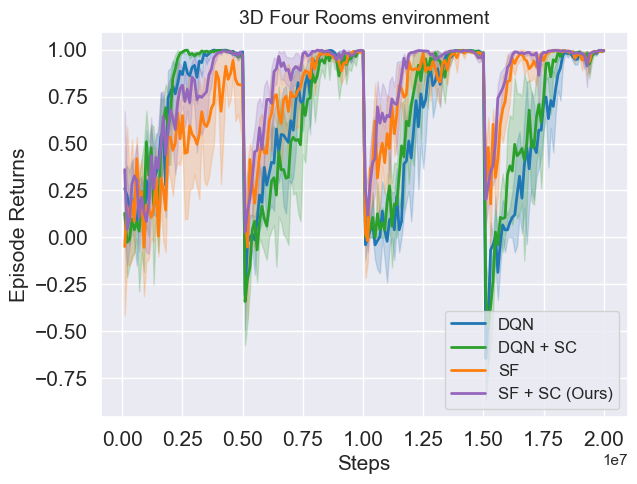

In [257]:
f, ax = plt.subplots(figsize=(6.8, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_agent"]],
    label=agents_new_names["simple_sf_agent"],
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

plt.title("3D Four Rooms environment", fontsize=14)
plt.xlabel("Steps", fontsize=15)
plt.ylabel("Episode Returns", fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
filename = "avg_episode_returns_training_plot_fourrooms_slippery" + "_consolidating_sf_leads_to_improvements"
plt.savefig(filename + ".pdf")
plt.show()

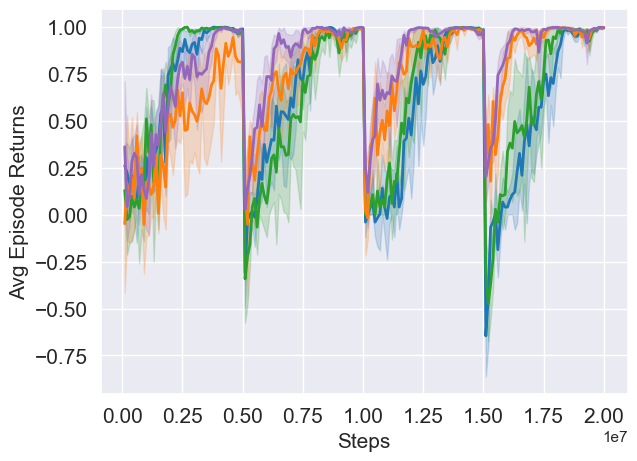

In [258]:
f, ax = plt.subplots(figsize=(6.8, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label="Non-Predictive",
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label="Non-Predictive + SC",
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_agent"]],
    label="Predictive",
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label="Predictive + SC",
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

plt.title("", fontsize=14)
plt.xlabel("Steps", fontsize=15)
plt.ylabel("Avg Episode Returns", fontsize=15)
# plt.legend(loc="lower right", fontsize=12)
plt.legend().set_visible(False)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
filename = "avg_episode_returns_training_plot_fourrooms_slippery" + "_consolidating_sf_leads_to_improvements_simplified"
plt.savefig(filename + ".pdf")
plt.show()

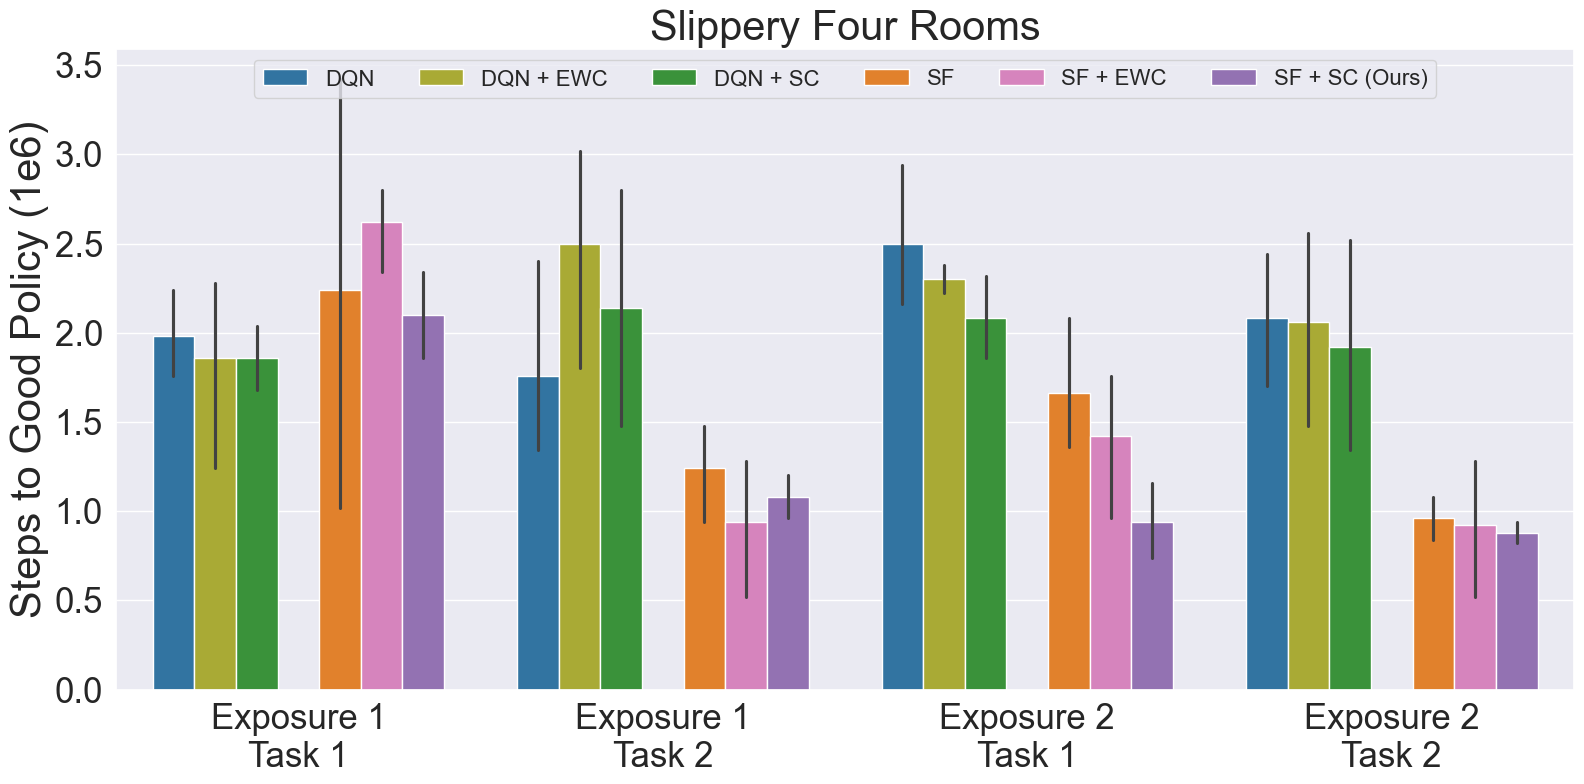

In [259]:
rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN",
    "DQN + EWC",
    "DQN + SC",
    " ",
    "SF",
    "SF + EWC",
    "SF + SC (Ours)",
]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

# === Plotting ===
plt.figure(figsize=(16, 8))
ax = sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
)
# Remove spacer from legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[h for h, l in zip(handles, labels) if l != " "],
          labels=[l for l in labels if l != " "],
          title=None, loc="upper center", fontsize=16, ncol=len(agent_order))

ax.yaxis.get_offset_text().set_visible(False)
plt.title("Slippery Four Rooms", fontsize=30)
plt.ylabel("Steps to Good Policy (1e6)", fontsize=30)
plt.xlabel("", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
filename = "Steps_to_good_policy_fourrooms_slippery"
plt.savefig(filename + ".pdf")
plt.tight_layout()
plt.show()


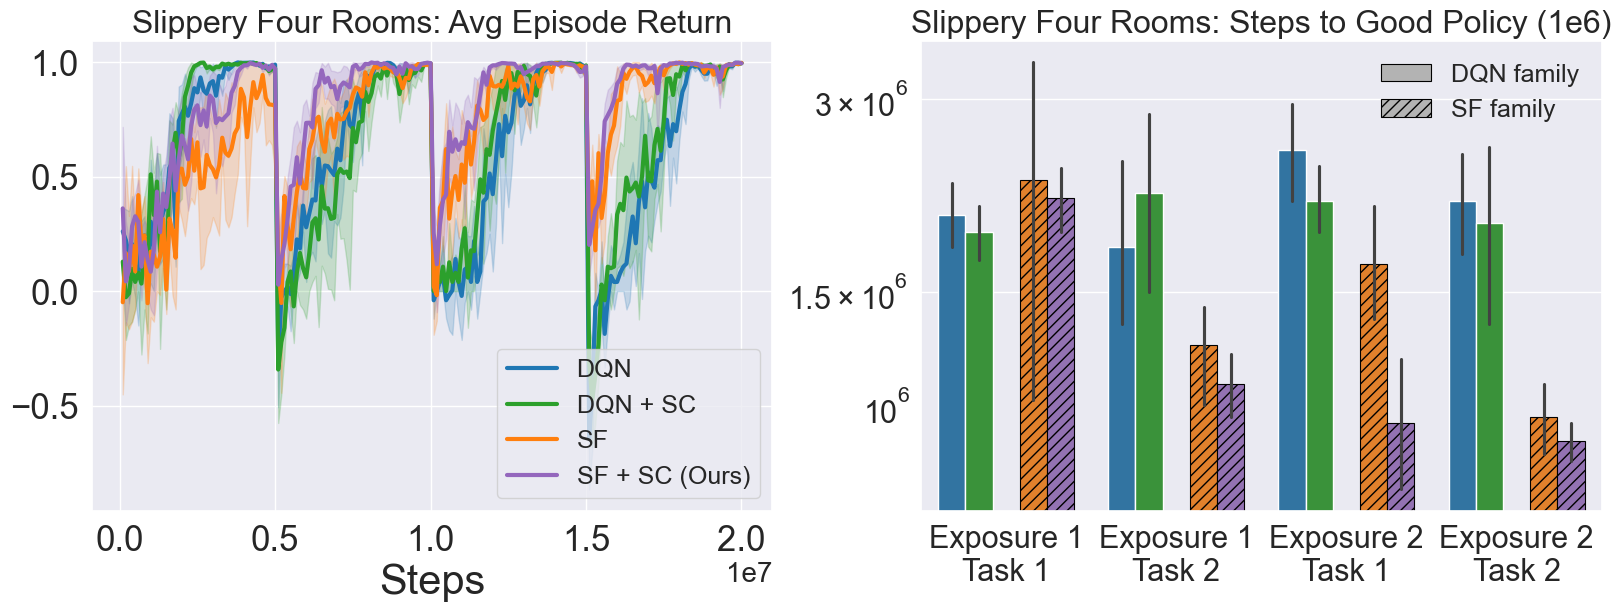

In [260]:
from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_agent"]],
    label=agents_new_names["simple_sf_agent"],
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN",
    "DQN + SC",
    " ",
    "SF",
    "SF + SC (Ours)",

]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

x_order = ["Exposure 1\nTask 1", "Exposure 1\nTask 2",
           "Exposure 2\nTask 1", "Exposure 2\nTask 2"]

# === Plotting ===
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    order=x_order,
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

# for i, bar in enumerate(axes[1].patches):
#     print(i, bar.get_x(), bar.get_height())

sf_set = {"SF", "SF + SC (Ours)"}  # only hatch SF
patterns = {"SF": "///", "SF + SC (Ours)": "///"}  # mapping Agent -> hatch pattern

patch_iter = iter(axes[1].patches)
for x in agent_order:
    for h in x_order:
        if x == " ":
            continue
        # check if this combo exists in the data
        if df_hits[(df_hits["task_label"] == h) & (df_hits["Agent"] == x)].empty:
            continue
        bar = next(patch_iter)
        if x in sf_set:
            bar.set_hatch(patterns[x])
            bar.set_edgecolor("black")
            bar.set_linewidth(0.8)
        # print(f"Bar: task={h}, agent={x}, height={bar.get_height()}")

# Create two dummy handles
# 1) Build the small “style” legend
plain_patch  = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                              label="DQN family")
hatched_patch = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                               hatch="///", label="SF family")

# 3) Add the legend INSIDE the axes first (to confirm it shows)
axes[1].legend(handles=[plain_patch, hatched_patch],
               title=None, loc="upper right", frameon=False, fontsize=18)

# fig.suptitle("Consolidating Successor Features mitigates forgetting beyond the first task", fontsize=18)

axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=14)
axes[0].set_title("Slippery Four Rooms: Avg Episode Return", fontsize=23)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].legend(loc="lower right", fontsize=18)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("")
axes[1].set_ylabel("", fontsize=28)
axes[1].set_title("Slippery Four Rooms: Steps to Good Policy (1e6)", fontsize=23)
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", labelsize=22)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

filename = "consolidating_q_values_vs_sf_analysis_slippery_fourrooms"
plt.savefig(filename + ".pdf")
plt.show()

Bar: task=Exposure 1
Task 1, agent=DQN + EWC, height=1860000.0
Bar: task=Exposure 1
Task 2, agent=DQN + EWC, height=2500000.0
Bar: task=Exposure 2
Task 1, agent=DQN + EWC, height=2300000.0
Bar: task=Exposure 2
Task 2, agent=DQN + EWC, height=2060000.0
Bar: task=Exposure 1
Task 1, agent=DQN + SC, height=1860000.0
Bar: task=Exposure 1
Task 2, agent=DQN + SC, height=2140000.0
Bar: task=Exposure 2
Task 1, agent=DQN + SC, height=2080000.0
Bar: task=Exposure 2
Task 2, agent=DQN + SC, height=1920000.0
Bar: task=Exposure 1
Task 1, agent=SF + EWC, height=2620000.0
Bar: task=Exposure 1
Task 2, agent=SF + EWC, height=940000.0
Bar: task=Exposure 2
Task 1, agent=SF + EWC, height=1420000.0
Bar: task=Exposure 2
Task 2, agent=SF + EWC, height=920000.0
Bar: task=Exposure 1
Task 1, agent=SF + SC (Ours), height=2100000.0
Bar: task=Exposure 1
Task 2, agent=SF + SC (Ours), height=1080000.0
Bar: task=Exposure 2
Task 1, agent=SF + SC (Ours), height=940000.0
Bar: task=Exposure 2
Task 2, agent=SF + SC (Ours), 

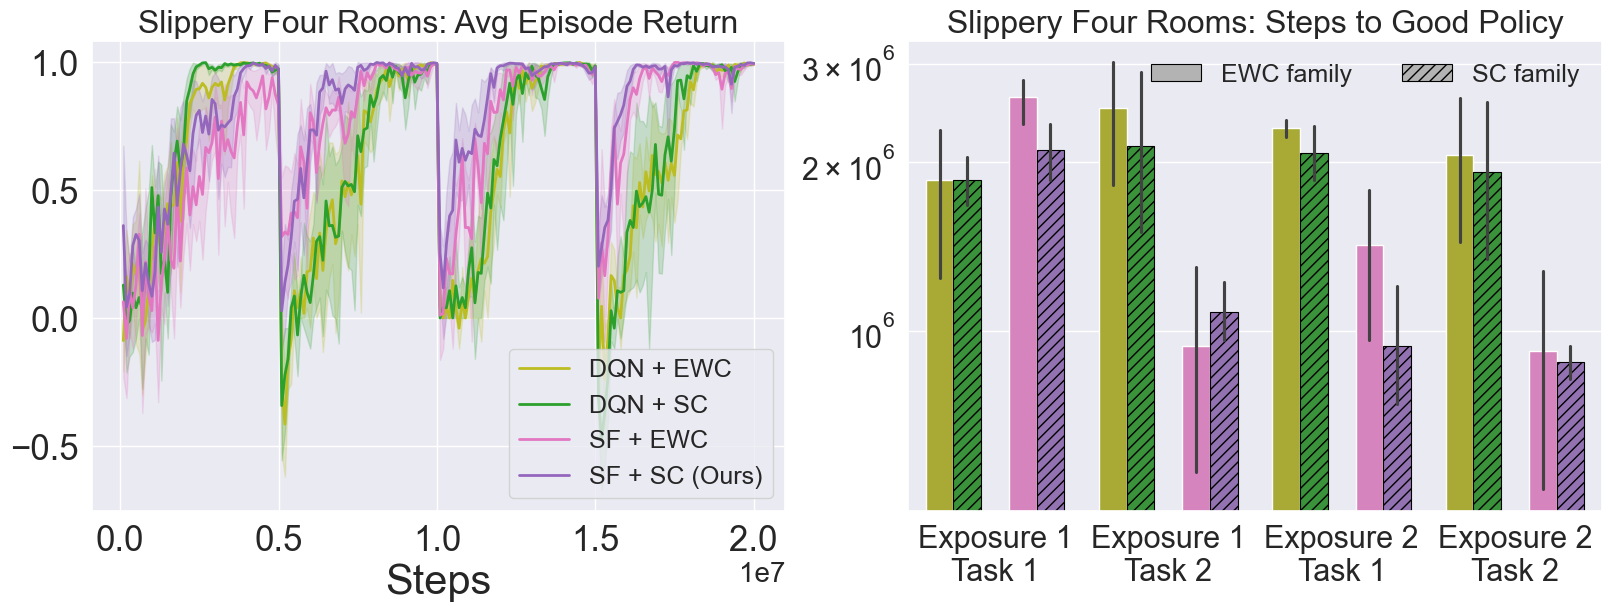

In [261]:
"""
This plot is to compare synaptic consolidation vs EWC
"""


fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_online_ewc"]],
    label=agents_new_names["simple_sf_online_ewc"],
    color=color_code[agents_new_names["simple_sf_online_ewc"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN + EWC",
    "DQN + SC",
    " ",
    "SF + EWC",
    "SF + SC (Ours)",

]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

# === Plotting ===
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

sf_set = {"DQN + SC", "SF + SC (Ours)"}  # only hatch SC
patterns = {"DQN + SC": "///", "SF + SC (Ours)": "///"}  # mapping Agent -> hatch pattern

patch_iter = iter(axes[1].patches)
for x in agent_order:
    for h in x_order:
        if x == " ":
            continue
        # check if this combo exists in the data
        if df_hits[(df_hits["task_label"] == h) & (df_hits["Agent"] == x)].empty:
            continue
        bar = next(patch_iter)
        if x in sf_set:
            bar.set_hatch(patterns[x])
            bar.set_edgecolor("black")
            bar.set_linewidth(0.8)
        print(f"Bar: task={h}, agent={x}, height={bar.get_height()}")

# fig.suptitle("Comparison of Synaptic and Elastic Weight Consolidation", fontsize=18)

plain_patch  = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                              label="EWC family")
hatched_patch = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                               hatch="///", label="SC family")

# 3) Add the legend INSIDE the axes first (to confirm it shows)
axes[1].legend(handles=[plain_patch, hatched_patch],
               title=None, loc="upper right", frameon=False, fontsize=18, ncol=2)

# axes[0].set_xlabel("Steps", fontsize=14)
# axes[0].set_ylabel("Avg Episode Return", fontsize=14)
# axes[0].tick_params(axis="x", labelsize=14)
# axes[0].tick_params(axis="y", labelsize=14)
# axes[0].legend(loc="lower right")
#
#
# axes[1].yaxis.get_offset_text().set_visible(False)
# axes[1].set_xlabel("")
# axes[1].set_ylabel("Steps to Good Policy (1e6)", fontsize=14)
# axes[1].tick_params(axis="x", labelsize=14)
# axes[1].tick_params(axis="y", labelsize=14)

axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=14)
axes[0].set_title("Slippery Four Rooms: Avg Episode Return", fontsize=23)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].legend(loc="lower right", fontsize=18)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("")
axes[1].set_ylabel("", fontsize=28)
axes[1].set_title("Slippery Four Rooms: Steps to Good Policy", fontsize=23)
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", labelsize=22)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

filename = "ewc_vs_synaptic_consolidation_slippery_fourrooms"
plt.savefig(filename + ".pdf")
plt.show()

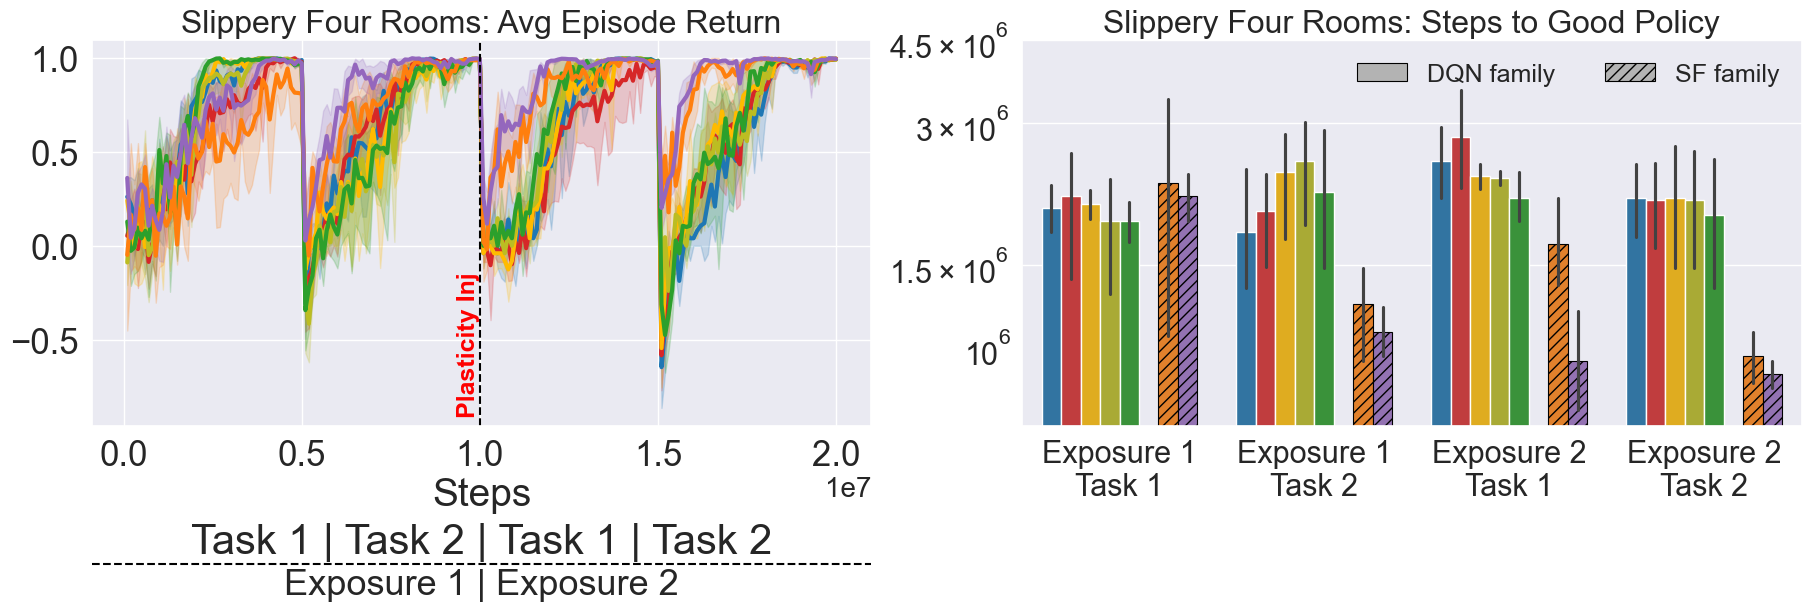

In [323]:
from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_cbp"]],
    label=agents_new_names["dqn_cbp"],
    color=color_code[agents_new_names["dqn_cbp"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_plasticity_injection"]],
    label=agents_new_names["DQN_plasticity_injection"],
    color=color_code[agents_new_names["DQN_plasticity_injection"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_agent"]],
    label=agents_new_names["simple_sf_agent"],
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN",
    "DQN + CBP",
    "DQN + P-last",
    "DQN + EWC",
    "DQN + SC",
    " ",
    "SF",
    "SF + SC (Ours)",

]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

x_order = ["Exposure 1\nTask 1", "Exposure 1\nTask 2",
           "Exposure 2\nTask 1", "Exposure 2\nTask 2"]

# === Plotting ===
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    order=x_order,
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

# for i, bar in enumerate(axes[1].patches):
#     print(i, bar.get_x(), bar.get_height())

sf_set = {"SF", "SF + SC (Ours)"}  # only hatch SF
patterns = {"SF": "///", "SF + SC (Ours)": "///"}  # mapping Agent -> hatch pattern

patch_iter = iter(axes[1].patches)
for x in agent_order:
    for h in x_order:
        if x == " ":
            continue
        # check if this combo exists in the data
        if df_hits[(df_hits["task_label"] == h) & (df_hits["Agent"] == x)].empty:
            continue
        bar = next(patch_iter)
        if x in sf_set:
            bar.set_hatch(patterns[x])
            bar.set_edgecolor("black")
            bar.set_linewidth(0.8)
        # print(f"Bar: task={h}, agent={x}, height={bar.get_height()}")

# Create two dummy handles
# 1) Build the small “style” legend
plain_patch  = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                              label="DQN family")
hatched_patch = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                               hatch="///", label="SF family")

# 3) Add the legend INSIDE the axes first (to confirm it shows)
axes[1].legend(handles=[plain_patch, hatched_patch],
               title=None, loc="upper right", frameon=False, fontsize=18, ncol=2)

# fig.suptitle("Consolidating Successor Features mitigates forgetting beyond the first task", fontsize=18)

axes[0].set_xlabel("Steps", fontsize=28)
axes[0].set_ylabel("", fontsize=14)
axes[0].set_title("Slippery Four Rooms: Avg Episode Return", fontsize=23)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
# axes[0].legend(loc="lower right", fontsize=20, ncols=2)
axes[0].legend().set_visible(False)
axes[0].xaxis.get_offset_text().set_fontsize(20)

ymin, ymax = axes[0].get_ylim()
axes[0].axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
axes[0].text(
    xline,                      # x position (same as line)
    ymin + 0.4 * (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18,
    fontweight="bold"
)

axes[0].text(
    0.5, -0.25,
    "Task 1 | Task 2 | Task 1 | Task 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=30
)

axes[0].hlines(
    y=-0.36, xmin=0, xmax=1,
    colors="black", linestyles="--", linewidth=1.5,
    transform=axes[0].transAxes, clip_on=False
)

axes[0].text(
    0.5, -0.37,
    "Exposure 1 | Exposure 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=26
)

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("")
axes[1].set_ylabel("", fontsize=28)
axes[1].set_title("Slippery Four Rooms: Steps to Good Policy", fontsize=23)
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", labelsize=22)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks
axes[1].set_ylim(top=4.5 * (10**6))

filename = "plasticity_sc_comparison_slippery_fourrooms"
plt.savefig(filename + ".pdf")
plt.show()

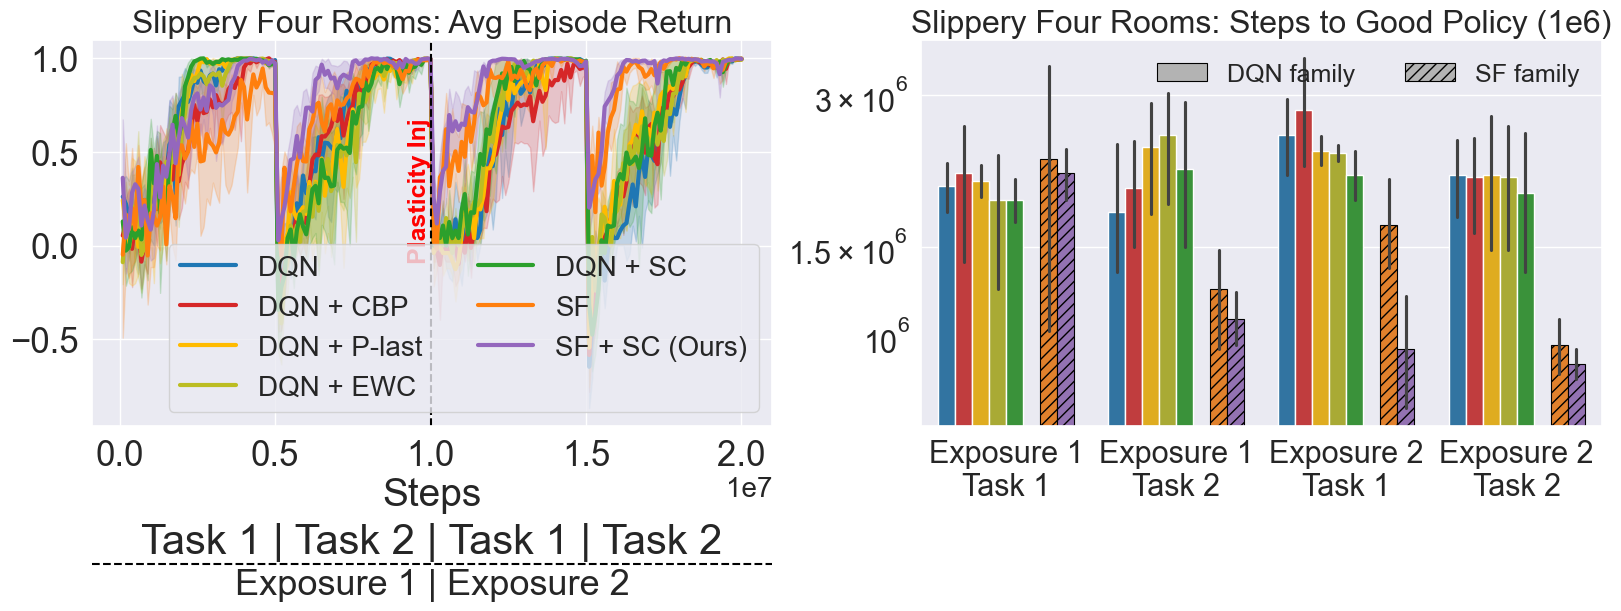

In [263]:
from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_cbp"]],
    label=agents_new_names["dqn_cbp"],
    color=color_code[agents_new_names["dqn_cbp"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_plasticity_injection"]],
    label=agents_new_names["DQN_plasticity_injection"],
    color=color_code[agents_new_names["DQN_plasticity_injection"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_agent"]],
    label=agents_new_names["simple_sf_agent"],
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN",
    "DQN + CBP",
    "DQN + P-last",
    "DQN + EWC",
    "DQN + SC",
    " ",
    "SF",
    "SF + SC (Ours)",

]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

x_order = ["Exposure 1\nTask 1", "Exposure 1\nTask 2",
           "Exposure 2\nTask 1", "Exposure 2\nTask 2"]

# === Plotting ===
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    order=x_order,
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

# for i, bar in enumerate(axes[1].patches):
#     print(i, bar.get_x(), bar.get_height())

sf_set = {"SF", "SF + SC (Ours)"}  # only hatch SF
patterns = {"SF": "///", "SF + SC (Ours)": "///"}  # mapping Agent -> hatch pattern

patch_iter = iter(axes[1].patches)
for x in agent_order:
    for h in x_order:
        if x == " ":
            continue
        # check if this combo exists in the data
        if df_hits[(df_hits["task_label"] == h) & (df_hits["Agent"] == x)].empty:
            continue
        bar = next(patch_iter)
        if x in sf_set:
            bar.set_hatch(patterns[x])
            bar.set_edgecolor("black")
            bar.set_linewidth(0.8)
        # print(f"Bar: task={h}, agent={x}, height={bar.get_height()}")

# Create two dummy handles
# 1) Build the small “style” legend
plain_patch  = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                              label="DQN family")
hatched_patch = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                               hatch="///", label="SF family")

# 3) Add the legend INSIDE the axes first (to confirm it shows)
axes[1].legend(handles=[plain_patch, hatched_patch],
               title=None, loc="upper right", frameon=False, fontsize=18, ncol=2)

# fig.suptitle("Consolidating Successor Features mitigates forgetting beyond the first task", fontsize=18)

axes[0].set_xlabel("Steps", fontsize=28)
axes[0].set_ylabel("", fontsize=14)
axes[0].set_title("Slippery Four Rooms: Avg Episode Return", fontsize=23)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].legend(loc="lower right", fontsize=20, ncols=2)
axes[0].xaxis.get_offset_text().set_fontsize(20)

ymin, ymax = axes[0].get_ylim()
axes[0].axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
axes[0].text(
    xline,                      # x position (same as line)
    ymin + 0.8 * (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18,
    fontweight="bold"
)

axes[0].text(
    0.5, -0.25,
    "Task 1 | Task 2 | Task 1 | Task 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=30
)

axes[0].hlines(
    y=-0.36, xmin=0, xmax=1,
    colors="black", linestyles="--", linewidth=1.5,
    transform=axes[0].transAxes, clip_on=False
)

axes[0].text(
    0.5, -0.37,
    "Exposure 1 | Exposure 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=26
)

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("")
axes[1].set_ylabel("", fontsize=28)
axes[1].set_title("Slippery Four Rooms: Steps to Good Policy (1e6)", fontsize=23)
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", labelsize=22)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

filename = "plasticity_sc_comparison_slippery_fourrooms"
plt.savefig(filename + ".pdf")
plt.show()

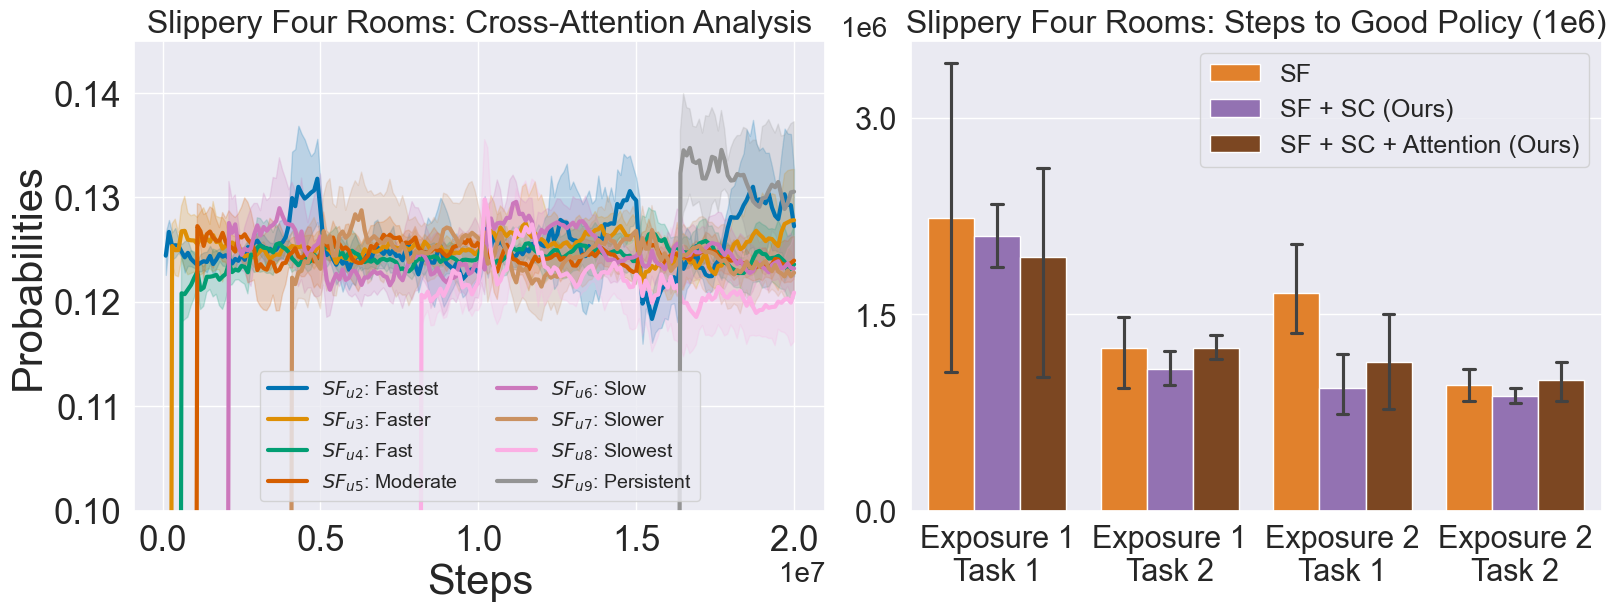

In [264]:
# Analysing the first attention mechanism
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

colors_attention = sns.color_palette("colorblind", 9)

# LEFT

sns.lineplot(
    x="eval/steps",
    y="train/attention_outputs_u0_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous_softmax_attention_diff_unique"]],
    label=r"$SF_{u2}$: Fastest",
    color=colors_attention[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="train/attention_outputs_u1_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous_softmax_attention_diff_unique"]],
    label=r"$SF_{u3}$: Faster",
    color=colors_attention[1],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


sns.lineplot(
    x="eval/steps",
    y="train/attention_outputs_u2_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous_softmax_attention_diff_unique"]],
    label=r"$SF_{u4}$: Fast",
    color=colors_attention[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="train/attention_outputs_u3_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous_softmax_attention_diff_unique"]],
    label=r"$SF_{u5}$: Moderate",
    color=colors_attention[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="train/attention_outputs_u4_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous_softmax_attention_diff_unique"]],
    label=r"$SF_{u6}$: Slow",
    color=colors_attention[4],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="train/attention_outputs_u5_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous_softmax_attention_diff_unique"]],
    label=r"$SF_{u7}$: Slower",
    color=colors_attention[5],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="train/attention_outputs_u6_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous_softmax_attention_diff_unique"]],
    label=r"$SF_{u8}$: Slowest",
    color=colors_attention[6],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="train/attention_outputs_u7_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous_softmax_attention_diff_unique"]],
    label=r"$SF_{u9}$: Persistent",
    color=colors_attention[7],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# sns.lineplot(
#     x="eval/steps",
#     y="train/attention_outputs_u8_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous_softmax_attention_diff_unique"]],
#     label=r"$SF_{u9}$: Enduring",
#     color=colors_attention[8],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
# )

rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "SF",
    "SF + SC (Ours)",
    "SF + SC + Attention (Ours)",

]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

# === Plotting ===
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=color_code,
    hue_order=agent_order,
    ax=axes[1],
    capsize=0.2,
)


# plt.title("Slippery Four Rooms", fontsize=30)
# plt.xlabel("Steps", fontsize=28)
# plt.ylabel("Attention Probabilities", fontsize=28)
# plt.legend(loc="lower center", fontsize=14, ncol=2)
# plt.xticks(fontsize=23)
# plt.yticks(fontsize=23)
# plt.ylim(0.1, 0.15)  # Set y-axis limits for the first subplot
# ax.xaxis.get_offset_text().set_fontsize(20)
# ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("Probabilities", fontsize=30)
axes[0].set_title("Slippery Four Rooms: Cross-Attention Analysis", fontsize=23)
axes[0].tick_params(axis="x", labelsize=25, which="both")
axes[0].tick_params(axis="y", labelsize=25)
# Set y-axis limits for each subplot
axes[0].set_ylim(0.1, 0.145)  # Set y-axis limits for the first subplot
axes[0].legend(loc="lower center", fontsize=14, ncol=2)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_title("Slippery Four Rooms: Steps to Good Policy (1e6)", fontsize=23)
axes[1].set_xlabel("", fontsize=30)
axes[1].set_ylabel("", fontsize=30)
axes[1].tick_params(axis="x", labelsize=22)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks
axes[1].legend(fontsize=18, loc="upper right", ncol=1, frameon=True)
axes[1].yaxis.get_offset_text().set_fontsize(20)
axes[1].yaxis.get_offset_text().set_x(-0.1)
axes[1].yaxis.get_offset_text().set_y(-0.2)

filename = "sf_attention_dist_slippery_fourrooms"
plt.savefig(filename + ".pdf")
plt.show()


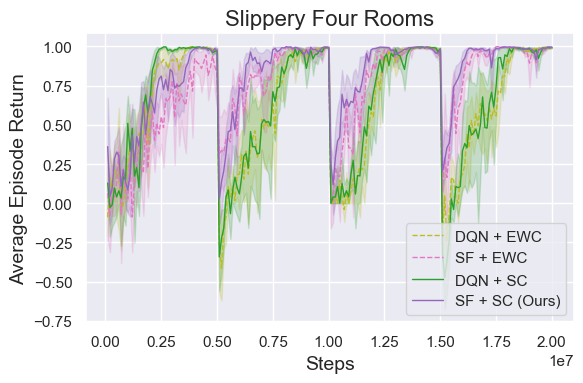

In [265]:
"""
This plot is to compare synaptic consolidation vs EWC
"""


plt.figure(figsize=(6,4))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5,
    linestyle='--',
    dashes=(1, 1)   # 2 on, 2 off -> fine dash
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_online_ewc"]],
    label=agents_new_names["simple_sf_online_ewc"],
    color=color_code[agents_new_names["simple_sf_online_ewc"]],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
    linestyle='--',
    dashes=(1, 1)   # 2 on, 2 off -> fine dash
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5,
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)


rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

plt.title("Slippery Four Rooms", fontsize=16)
plt.ylabel("Average Episode Return", fontsize=14)
plt.xlabel("Steps", fontsize=14)
plt.tight_layout()
plt.legend(loc="lower right")

filename = "ewc_vs_synaptic_consolidation_avg_episode_return_fourrooms_slippery"
plt.savefig(filename + ".pdf")
plt.tight_layout()
plt.show()

In [266]:
api = wandb.Api()
# Initialize Hydra and load the config directly
cfg = hydra.compose(config_name="full_train_miniworld_slippery_fix")
project_name = "continual_rl" + "_" + cfg.logging.mode + "_" + experiment
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

timescale_summary_list, timescale_config_list, timescale_name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "timescale" not in run.tags:
        continue

    if run.config["agent_feature_dim"] != 256:
        continue

    print(run.config["agent_name"])

    avg_episode_returns_history = run.scan_history(keys=["eval/avg_episode_returns"])
    avg_episode_return = [
        row["eval/avg_episode_returns"] for row in avg_episode_returns_history
    ]

    avg_episode_length_history = run.scan_history(keys=["eval/avg_episode_length"])
    avg_episode_length = [
        row["eval/avg_episode_length"] for row in avg_episode_length_history
    ]

    steps_history = run.scan_history(keys=["eval/steps"])

    steps = [row["eval/steps"] for row in steps_history]

    task_history = run.scan_history(keys=["train/task"])
    task = [row["train/task"] for row in task_history]


    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue

    print("len(steps): ", len(steps))
    print("len(avg_episode_return): ", len(avg_episode_return))
    print("len(avg_episode_length): ", len(avg_episode_length))

    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp2 = dict()
    temp2["eval/steps"] = steps
    temp2["eval/episode_return"] = avg_episode_return
    temp2["eval/avg_episode_length"] = avg_episode_length
    temp2["train/task"] = task

    temp2["eval/mvg_avg_episode_length"] = np.convolve(
        temp2["eval/avg_episode_length"],
        np.ones((moving_average_window,))
        / moving_average_window,
        mode="valid",
    )

    temp2["eval/mvg_avg_episode_length"] = np.pad(
        temp2["eval/mvg_avg_episode_length"],
        (moving_average_window - 1, 0),
        "constant",
        constant_values=cfg.domain.max_episode_length,
    )


    timescale_summary_list.append(temp2)
    del temp2

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    timescale_config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    timescale_name_list.append(run.name)

num_of_runs: 91
idx: 0
idx: 10
idx: 20
sf_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
sf_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
sf_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
sf_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
sf_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
sf_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
sf_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
idx: 30
idx: 40
idx: 50
sf_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
sf_consolidation_params_continuous
len(st

In [267]:
timescale_runs_df = pd.DataFrame(
        {"summary": timescale_summary_list, "config": timescale_config_list, "name": timescale_name_list}
    )

print(timescale_runs_df)

# create a new column using agent_name
timescale_runs_df["agent_name"] = timescale_runs_df["config"].apply(lambda x: x["agent_name"])

# create a new column using agents_seed
timescale_runs_df["agent_seed"] = timescale_runs_df["config"].apply(lambda x: x["agent_seed"])


# create a new column using agent_num_beakers
timescale_runs_df["agent_num_beakers"] = timescale_runs_df["config"].apply(lambda x: x["agent_num_beakers"])

                                              summary  \
0   {'eval/steps': [100000, 200000, 300000, 400000...   
1   {'eval/steps': [100000, 200000, 300000, 400000...   
2   {'eval/steps': [100000, 200000, 300000, 400000...   
3   {'eval/steps': [100000, 200000, 300000, 400000...   
4   {'eval/steps': [100000, 200000, 300000, 400000...   
5   {'eval/steps': [100000, 200000, 300000, 400000...   
6   {'eval/steps': [100000, 200000, 300000, 400000...   
7   {'eval/steps': [100000, 200000, 300000, 400000...   
8   {'eval/steps': [100000, 200000, 300000, 400000...   
9   {'eval/steps': [100000, 200000, 300000, 400000...   
10  {'eval/steps': [100000, 200000, 300000, 400000...   
11  {'eval/steps': [100000, 200000, 300000, 400000...   
12  {'eval/steps': [100000, 200000, 300000, 400000...   
13  {'eval/steps': [100000, 200000, 300000, 400000...   
14  {'eval/steps': [100000, 200000, 300000, 400000...   
15  {'eval/steps': [100000, 200000, 300000, 400000...   
16  {'eval/steps': [100000, 200

In [268]:
print(timescale_runs_df)

                                              summary  \
0   {'eval/steps': [100000, 200000, 300000, 400000...   
1   {'eval/steps': [100000, 200000, 300000, 400000...   
2   {'eval/steps': [100000, 200000, 300000, 400000...   
3   {'eval/steps': [100000, 200000, 300000, 400000...   
4   {'eval/steps': [100000, 200000, 300000, 400000...   
5   {'eval/steps': [100000, 200000, 300000, 400000...   
6   {'eval/steps': [100000, 200000, 300000, 400000...   
7   {'eval/steps': [100000, 200000, 300000, 400000...   
8   {'eval/steps': [100000, 200000, 300000, 400000...   
9   {'eval/steps': [100000, 200000, 300000, 400000...   
10  {'eval/steps': [100000, 200000, 300000, 400000...   
11  {'eval/steps': [100000, 200000, 300000, 400000...   
12  {'eval/steps': [100000, 200000, 300000, 400000...   
13  {'eval/steps': [100000, 200000, 300000, 400000...   
14  {'eval/steps': [100000, 200000, 300000, 400000...   
15  {'eval/steps': [100000, 200000, 300000, 400000...   
16  {'eval/steps': [100000, 200

In [269]:
timescale_runs_df["agent_name"] = timescale_runs_df["agent_name"].replace(
    "sf_consolidation_params_continuous", agents_new_names["sf_consolidation_params_continuous"]
)

In [270]:
print(timescale_runs_df.columns.tolist())

['summary', 'config', 'name', 'agent_name', 'agent_seed', 'agent_num_beakers']


In [271]:
# remove the name and config column
timescale_runs_df = timescale_runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
timescale_runs_df = pd.concat(
    [timescale_runs_df.drop(["summary"], axis=1), timescale_runs_df["summary"].apply(pd.Series)], axis=1
)

# reset index
timescale_runs_df = timescale_runs_df.reset_index(drop=True)

print(timescale_runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
timescale_runs_df = timescale_runs_df.explode(list(timescale_runs_df.columns[3:])).reset_index(drop=True)

print(timescale_runs_df.shape)

print("dataframe: ", timescale_runs_df)

        agent_name  agent_seed  agent_num_beakers  \
0   SF + SC (Ours)         388                  9   
1   SF + SC (Ours)         485                  9   
2   SF + SC (Ours)          97                  9   
3   SF + SC (Ours)         582                  9   
4   SF + SC (Ours)         291                  9   
5   SF + SC (Ours)         679                  9   
6   SF + SC (Ours)         194                  9   
7   SF + SC (Ours)         582                  6   
8   SF + SC (Ours)         291                  6   
9   SF + SC (Ours)         194                  6   
10  SF + SC (Ours)         388                  6   
11  SF + SC (Ours)         485                  6   
12  SF + SC (Ours)          97                  6   
13  SF + SC (Ours)          97                  3   
14  SF + SC (Ours)         388                  3   
15  SF + SC (Ours)         485                  3   
16  SF + SC (Ours)         679                  3   
17  SF + SC (Ours)         194                

In [272]:
# runs_df["eval/cumulative_episode_reward"] = runs_df["eval/episode_reward"].cumsum()

print(timescale_runs_df.columns)

timescale_runs_df = timescale_runs_df.sort_values(["agent_num_beakers", "agent_seed","eval/steps"])

timescale_runs_df["agent_name_pretty"] = timescale_runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(timescale_runs_df.columns)
# print(timescale_runs_df["agent_num_beakers","norm_cum_reward"])

Index(['agent_name', 'agent_seed', 'agent_num_beakers', 'eval/steps',
       'eval/episode_return', 'eval/avg_episode_length', 'train/task',
       'eval/mvg_avg_episode_length'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'agent_num_beakers', 'eval/steps',
       'eval/episode_return', 'eval/avg_episode_length', 'train/task',
       'eval/mvg_avg_episode_length', 'agent_name_pretty'],
      dtype='object')


In [273]:
runs_df_sf_simple = runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_agent"]]

runs_df_sf_simple["eval/episode_rewards_num"] = (
    runs_df_sf_simple["eval/episode_return"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

runs_df_sf_simple.loc[:, "agent_name_pretty"] = (
    runs_df_sf_simple["agent_name"].str.replace(" + ", "\n +", regex=False)
)

runs_df_sf_simple = runs_df_sf_simple[["agent_name", "agent_seed", "eval/steps", "eval/episode_return", "agent_name_pretty", "eval/episode_rewards_num", "eval/avg_episode_length"]]

print(runs_df_sf_simple.columns)


timescale_runs_df = pd.concat([timescale_runs_df, runs_df_sf_simple], ignore_index=True)

print(timescale_runs_df["agent_num_beakers"].unique())

Index(['agent_name', 'agent_seed', 'eval/steps', 'eval/episode_return',
       'agent_name_pretty', 'eval/episode_rewards_num',
       'eval/avg_episode_length'],
      dtype='object')
[ 3.  6.  9. nan]


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_11425/1093857142.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  runs_df_sf_simple["eval/episode_rewards_num"] = (
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_11425/1093857142.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  runs_df_sf_simple.loc[:, "agent_name_pretty"] = (


In [274]:
runs_df_simple_sf = runs_df[runs_df["agent_name"] == "SF"]
runs_df_simple_sf["agent_num_beakers"] = 0
print(runs_df_simple_sf)

    agent_name  agent_seed  eval/steps eval/episode_return  \
0           SF          97      100000               0.375   
1           SF          97      200000                -0.2   
2           SF          97      300000                   0   
3           SF          97      400000                   0   
4           SF          97      500000                 0.2   
..         ...         ...         ...                 ...   
995         SF         679  19600000.0            0.988372   
996         SF         679  19700000.0            0.977099   
997         SF         679  19800000.0            0.995012   
998         SF         679  19900000.0            0.987879   
999         SF         679  20000000.0                   1   

    eval/avg_episode_length train/task eval/mvg_avg_episode_length  \
0                  2398.875          0                      4000.0   
1                    3471.4          0                      4000.0   
2                      4001          0       

/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_11425/3293517594.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  runs_df_simple_sf["agent_num_beakers"] = 0


In [275]:
df_hits_simple_sf = df_hits[df_hits["agent_name"] == "simple_sf_agent"]
df_hits_simple_sf["agent_num_beakers"] = 0
print(df_hits_simple_sf["agent_name"].unique())

['simple_sf_agent']


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_11425/2578158620.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hits_simple_sf["agent_num_beakers"] = 0


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_11425/341360522.py:199: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.25)


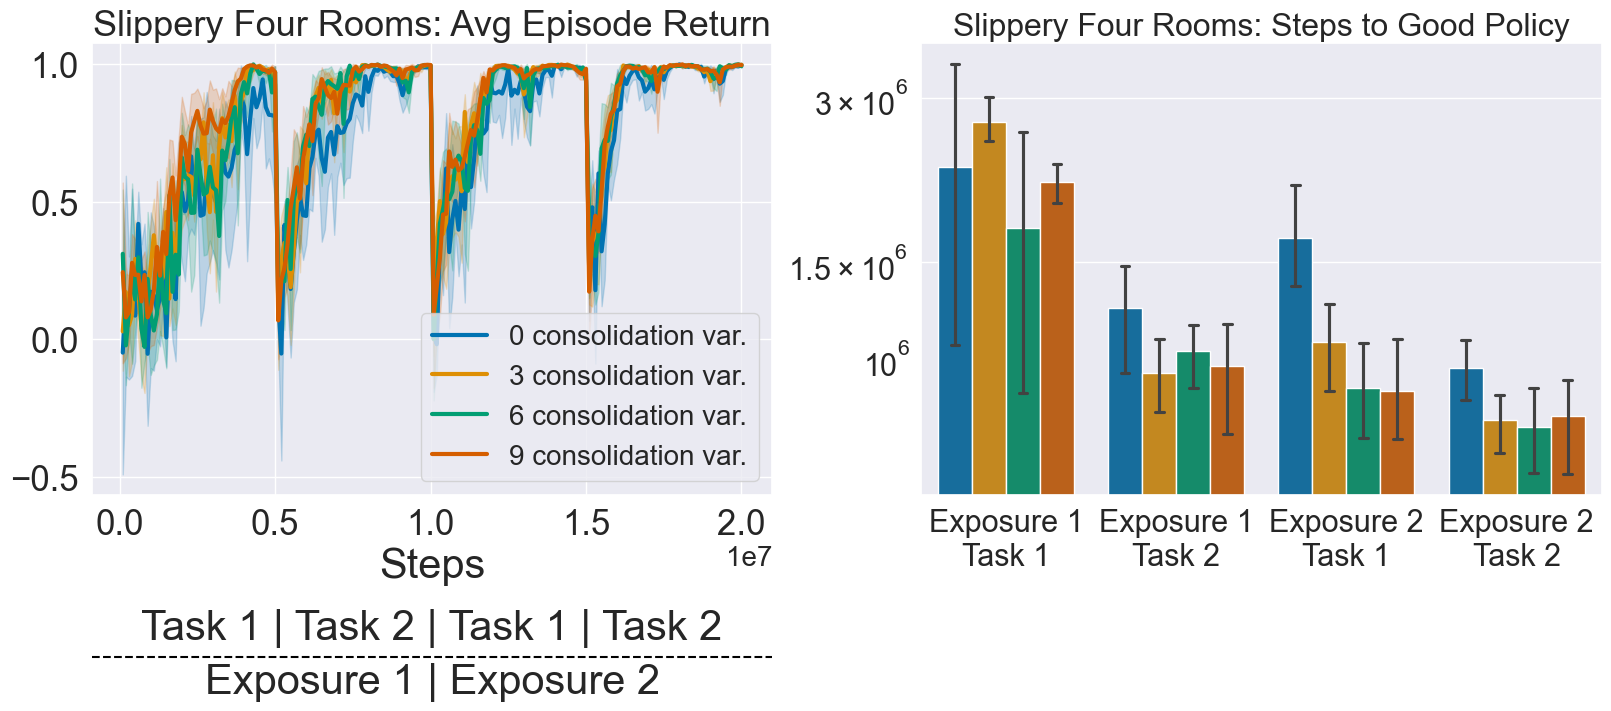

In [276]:
# Comparing with different number of beakers
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

colors = sns.color_palette("colorblind", 4)

# LEFT

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_agent"]],
    label="0 consolidation var.",
    color=colors[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 3],
    label= "3 consolidation var.",
    color=colors[1],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 6],
    label= "6 consolidation var.",
    color=colors[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 9],
    label= "9 consolidation var.",
    color=colors[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# RIGHT
agent_num_beakers_order = [
    "0",
    "3",
    "6",
    "9",
]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

colors_mapping = {
    0: colors[0],
    3: colors[1],
    6: colors[2],
    9: colors[3],
}

timescale_rows = []


for run_idx, (temp, cfg, name) in enumerate(zip(timescale_summary_list, timescale_config_list, timescale_name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        timescale_rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
            "agent_num_beakers": cfg.get("agent_num_beakers", f"run{run_idx}"),
        })

df_hits_timescale = pd.DataFrame(timescale_rows)

df_hits_timescale_merged = pd.concat([df_hits_timescale, df_hits_simple_sf], ignore_index=True)

df_hits_timescale_merged["task_label"] = df_hits["task"].map(task_labels)

sns.barplot(
    data=df_hits_timescale_merged,
    x="task_label",
    y="first_below_local",
    hue="agent_num_beakers",
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=colors_mapping,
    # hue_order=agent_num_beakers_order,
    ax=axes[1],
    legend=False,
    capsize=0.2,
)

# print(df_hits_timescale_merged)
#
# last_rows = df_hits_timescale_merged.groupby(["agent_num_beakers", "agent_seed", ], as_index=False).tail(1)
# df_sum = (
#     df_hits_timescale_merged.groupby(["agent_num_beakers", "agent_seed"], as_index=False)["eval/episode_return"].sum()
# )
# print(last_rows)
# sns.barplot(data=df_sum, x="agent_num_beakers", y="eval/episode_return", ax=axes[1], errorbar="se", capsize=0.2, palette=colors, hue="agent_num_beakers", legend=False)

# sns.barplot(
#     data=df_hits,
#     x="task_label",
#     y="first_below_local",
#     hue="Agent",
#     dodge=True,
#     estimator="mean",   # now mean per agent_name per task
#     errorbar="ci",
#     palette=palette_with_space,
#     hue_order=agent_order,
#     ax=axes[1],
# )


axes[0].set_title("Slippery Four Rooms: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
axes[0].legend(loc="lower right", fontsize=20)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[0].text(
    0.5, -0.25,
    "Task 1 | Task 2 | Task 1 | Task 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=30
)

axes[0].hlines(
    y=-0.36, xmin=0, xmax=1,
    colors="black", linestyles="--", linewidth=1.5,
    transform=axes[0].transAxes, clip_on=False
)

axes[0].text(
    0.5, -0.37,
    "Exposure 1 | Exposure 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=30
)

# axes[1].set_xlabel("Num of Consolidation Variables", fontsize=30)
# axes[1].set_ylabel("", fontsize=30)
# axes[1].set_title("Slippery Four Rooms: Cumulative Returns", fontsize=26)
# axes[1].tick_params(axis="x", labelsize=23)
# axes[1].tick_params(axis="y", labelsize=22)
# # axes[1].set_yscale("log")
# axes[1].tick_params(axis="y", labelsize=22, which="both")

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("")
axes[1].set_ylabel("", fontsize=28)
axes[1].set_title("Slippery Four Rooms: Steps to Good Policy", fontsize=23)
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", labelsize=22)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

fig.subplots_adjust(bottom=0.25)

filename = "num_beakers_analysis_slippery_fourrooms"
plt.savefig(filename + ".pdf")
plt.show()


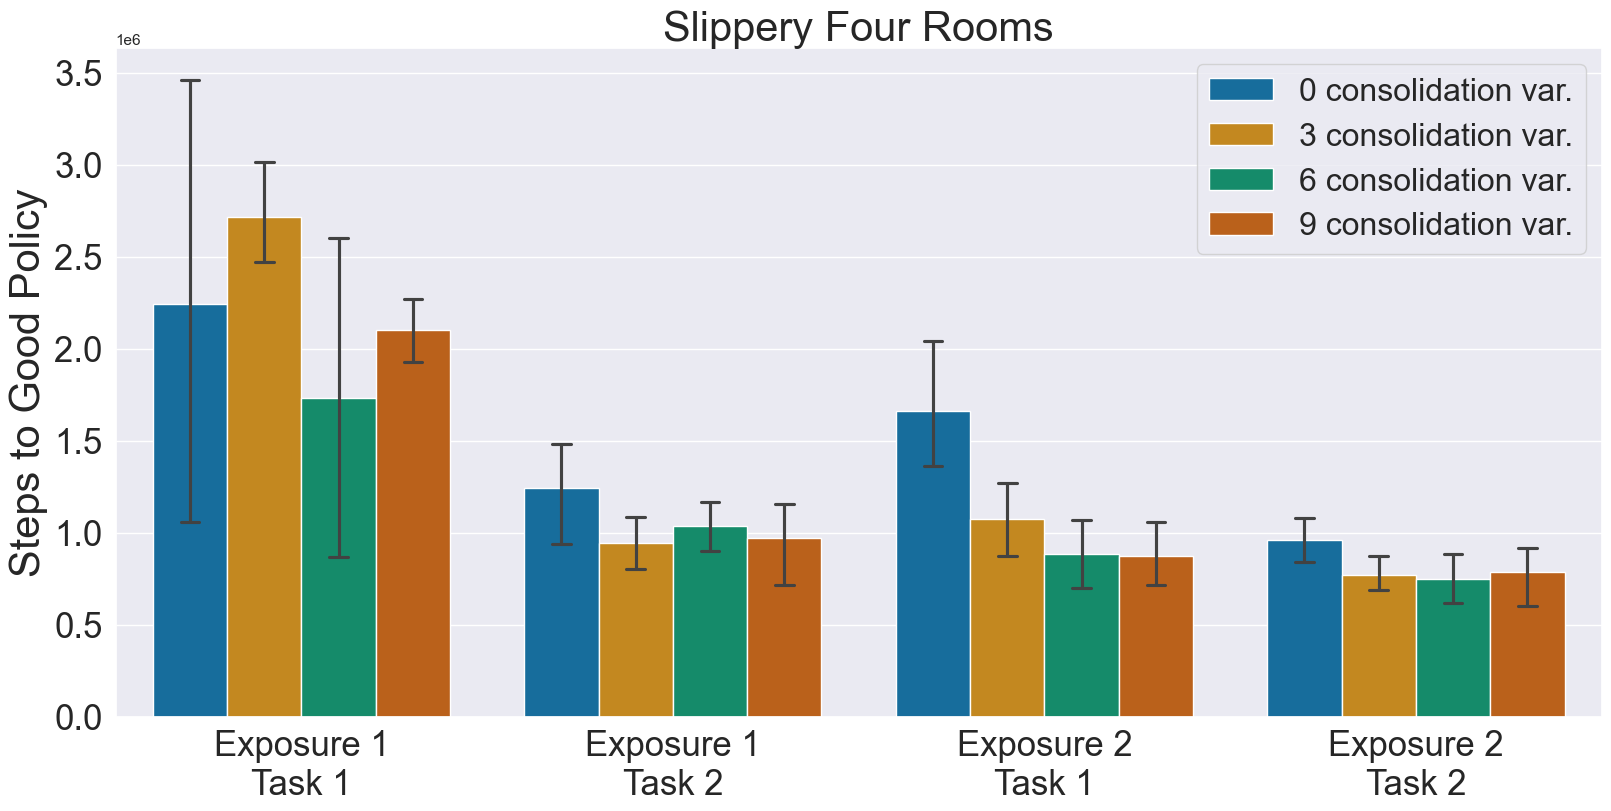

In [277]:
plt.figure(figsize=(16, 8), constrained_layout=True)

agent_num_beakers_order = [
    "0",
    "3",
    "6",
    "9",
]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

colors_mapping = {
    0: colors[0],
    3: colors[1],
    6: colors[2],
    9: colors[3],
}

# colors_mapping = {
#     "0": colors[0],
#     "3": colors[1],
#     "6": colors[2],
#     "9": colors[3],
# }

timescale_rows = []


for run_idx, (temp, cfg, name) in enumerate(zip(timescale_summary_list, timescale_config_list, timescale_name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        timescale_rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
            "agent_num_beakers": cfg.get("agent_num_beakers", f"run{run_idx}"),
        })

df_hits_timescale = pd.DataFrame(timescale_rows)

df_hits_timescale_merged = pd.concat([df_hits_timescale, df_hits_simple_sf], ignore_index=True)

df_hits_timescale_merged["task_label"] = df_hits["task"].map(task_labels)

ax = sns.barplot(
    data=df_hits_timescale_merged,
    x="task_label",
    y="first_below_local",
    hue="agent_num_beakers",
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=colors_mapping,
    # hue_order=agent_num_beakers_order,
    capsize=0.2,

)

label_map = {
    "0": "0 consolidation var.",
    "3": "3 consolidation var.",
    "6": "6 consolidation var.",
    "9": "9 consolidation var."
}

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    [label_map.get(l, l) for l in labels],
    fontsize=23
)

ax.yaxis.get_offset_text().set_visible(True)
plt.title("Slippery Four Rooms", fontsize=30)
plt.ylabel("Steps to Good Policy", fontsize=30)
plt.xlabel("", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
filename = "Steps_to_good_policy_fourrooms_slippery_timescale_variables"
plt.savefig(filename + ".pdf")
plt.show()


In [278]:
from typing import List, Dict, Any, Hashable

In [279]:
print(runs_df.columns.unique())

Index(['agent_name', 'agent_seed', 'eval/steps', 'eval/episode_return',
       'eval/avg_episode_length', 'train/task', 'eval/mvg_avg_episode_length',
       'train/attention_outputs_u8_mean', 'train/attention_outputs_u7_mean',
       'train/attention_outputs_u6_mean', 'train/attention_outputs_u5_mean',
       'train/attention_outputs_u4_mean', 'train/attention_outputs_u3_mean',
       'train/attention_outputs_u2_mean', 'train/attention_outputs_u1_mean',
       'train/attention_outputs_u0_mean'],
      dtype='object')


In [280]:
print(runs_df["train/task"])

0       0
1       0
2       0
3       0
4       0
       ..
9395    3
9396    3
9397    3
9398    3
9399    3
Name: train/task, Length: 9400, dtype: object


In [281]:
runs_df = runs_df.copy()

# Map original tasks to collapsed task IDs (0/1)
task_map = {
    0: 0,
    1: 1,
    2: 0,   # A again
    3: 1    # B again
}

runs_df["train/task_clean"] = runs_df["train/task"].map(task_map)

# Exposure index: 0 for original tasks (0,1), 1 for (2,3)
runs_df["exposure_idx"] = runs_df["train/task"].apply(lambda x: 0 if x in [0,1] else 1)

In [282]:
print(runs_df)

     agent_name  agent_seed  eval/steps eval/episode_return  \
0            SF          97      100000               0.375   
1            SF          97      200000                -0.2   
2            SF          97      300000                   0   
3            SF          97      400000                   0   
4            SF          97      500000                 0.2   
...         ...         ...         ...                 ...   
9395  DQN + CBP         679  19600000.0            0.992395   
9396  DQN + CBP         679  19700000.0            0.961957   
9397  DQN + CBP         679  19800000.0             0.98568   
9398  DQN + CBP         679  19900000.0            0.986637   
9399  DQN + CBP         679  20000000.0            0.977778   

     eval/avg_episode_length train/task eval/mvg_avg_episode_length  \
0                   2398.875          0                      4000.0   
1                     3471.4          0                      4000.0   
2                       4001  

In [283]:
print(runs_df["exposure_idx"])

0       0
1       0
2       0
3       0
4       0
       ..
9395    1
9396    1
9397    1
9398    1
9399    1
Name: exposure_idx, Length: 9400, dtype: int64


In [284]:
def infer_switch_steps_from_interval(
    max_step: int,
    interval: int = 5_000_000
) -> List[int]:
    """
    Create a list of switch steps: [interval, 2*interval, 3*interval, ...]
    up to max_step.
    """
    switches = []
    k = 1
    while k * interval <= max_step:
        switches.append(k * interval)
        k += 1
    return switches

In [285]:
def get_task_at_step(df: pd.DataFrame, step: int) -> Hashable:
    """
    Return the task_id (from 'train/task') that is active immediately AFTER
    a given step, based on the first eval row with 'eval/steps' >= step.
    """
    df_sorted = df.sort_values('eval/steps')
    idx = df_sorted['eval/steps'].searchsorted(step, side="left")
    if idx >= len(df_sorted):
        raise ValueError(f"No evals at or after step {step}.")
    return df_sorted.iloc[idx]['train/task_clean']

In [286]:
def compute_pre_post_drop_eval(
    df: pd.DataFrame,
    switch_steps: List[int],
    window_steps: int = 200_000,
    perf_col: str = "eval/episode_return",
) -> pd.DataFrame:
    """
    Compute pre- and post-window performance and the drop around each switch.

    df must contain:
        - 'eval/steps'
        - 'train/task'
        - perf_col (default: 'eval/episode_return')

    For a switch at S:
        pre-window  = eval rows with S - window_steps <= eval/steps <  S
        post-window = eval rows with S < eval/steps <= S + window_steps

    Returns a DataFrame with one row per switch:
        'switch_step', 'task_after_switch', 'pre_mean', 'post_mean',
        'delta', 'n_pre', 'n_post'
    """
    df = df.copy().sort_values('eval/steps')

    rows = []
    for S in switch_steps:
        task_after = get_task_at_step(df, S)

        pre_mask = (
            (df['eval/steps'] >= S - window_steps) &
            (df['eval/steps'] < S)
        )
        post_mask = (
            (df['eval/steps'] > S) &
            (df['eval/steps'] <= S + window_steps)
        )

        pre_vals = df.loc[pre_mask, perf_col]
        post_vals = df.loc[post_mask, perf_col]

        pre_mean = pre_vals.mean() if len(pre_vals) > 0 else np.nan
        post_mean = post_vals.mean() if len(post_vals) > 0 else np.nan
        delta = pre_mean - post_mean

        rows.append(dict(
            switch_step=S,
            task_after_switch=task_after,
            pre_mean=pre_mean,
            post_mean=post_mean,
            delta=delta,
            n_pre=len(pre_vals),
            n_post=len(post_vals),
        ))

    return pd.DataFrame(rows)


In [287]:
def compute_task_max_perf_eval(
    df: pd.DataFrame,
    perf_col: str = "eval/episode_return",
) -> Dict[Hashable, float]:
    """
    Compute the maximum eval performance per task across the whole run.

    Returns dict: task_id -> max(perf_col) over all eval rows of that task.
    """
    return (
        df
        .groupby('train/task_clean')[perf_col]
        .max()
        .to_dict()
    )


In [288]:
def compute_adaptation_times_eval(
    df: pd.DataFrame,
    switch_steps: List[int],
    perf_col: str = "eval/episode_return",
    alpha: float = 0.8,
) -> pd.DataFrame:
    """
    For each switch, compute adaptation time in STEPS:
    number of steps from switch until eval performance reaches
    alpha * P_max(task_after_switch), where P_max is the best eval performance
    seen for that task across the entire run.

    df must contain:
        - 'eval/steps'
        - 'train/task'
        - perf_col

    Returns a DataFrame with one row per switch:
        'switch_step', 'task_after_switch', 'P_max', 'target', 'adapt_steps'
    """
    df = df.copy().sort_values('eval/steps')
    task_max = compute_task_max_perf_eval(df, perf_col=perf_col)

    rows = []
    for S in switch_steps:
        task_after = get_task_at_step(df, S)
        P_max = task_max[task_after]
        target = alpha * P_max

        # All evals after the switch on the new task
        mask_after = (
            (df['eval/steps'] >= S) &
            (df['train/task_clean'] == task_after)
        )
        df_after = df.loc[mask_after, ['eval/steps', perf_col]]

        adapt_steps = np.nan
        for _, row in df_after.iterrows():
            if row[perf_col] >= target:
                adapt_steps = row['eval/steps'] - S
                break

        rows.append(dict(
            switch_step=S,
            task_after_switch=task_after,
            P_max=P_max,
            target=target,
            adapt_steps=adapt_steps,
        ))

    return pd.DataFrame(rows)

In [289]:
def get_task_exposures_eval(
    df: pd.DataFrame,
) -> Dict[Hashable, List[Dict[str, Any]]]:
    """
    Identify contiguous exposures for each task in eval logs.

    df must contain:
        - 'eval/steps'
        - 'train/task'

    Returns:
        dict: task_id -> list of exposures
            each exposure is dict with:
                'start_step', 'end_step', 'indices' (row indices in df)
    """
    df_use = df.copy().sort_values('eval/steps').reset_index(drop=True)

    exposures_by_task: Dict[Hashable, List[Dict[str, Any]]] = {}

    if len(df_use) == 0:
        return exposures_by_task

    current_task = df_use.loc[0, 'train/task_clean']
    start_idx = 0

    for i in range(1, len(df_use)):
        t = df_use.loc[i, 'train/task_clean']
        if t != current_task:
            # end current exposure
            end_idx = i - 1
            task_data = exposures_by_task.setdefault(current_task, [])
            task_data.append(dict(
                start_step=df_use.loc[start_idx, 'eval/steps'],
                end_step=df_use.loc[end_idx, 'eval/steps'],
                indices=list(range(start_idx, end_idx + 1)),
            ))
            # start new exposure
            current_task = t
            start_idx = i

    # Close final exposure
    end_idx = len(df_use) - 1
    task_data = exposures_by_task.setdefault(current_task, [])
    task_data.append(dict(
        start_step=df_use.loc[start_idx, 'eval/steps'],
        end_step=df_use.loc[end_idx, 'eval/steps'],
        indices=list(range(start_idx, end_idx + 1)),
    ))

    return exposures_by_task

In [290]:
def compute_adaptation_for_exposures_eval(
    df: pd.DataFrame,
    perf_col: str = "eval/episode_return",
    alpha: float = 0.8,
) -> pd.DataFrame:
    """
    Compute adaptation time per exposure (first, second, third, ...)
    for each task, in STEPS, using only eval logs.

    For each contiguous block (exposure) of a task:
        - find P_max(task) over all evals for that task
        - set target = alpha * P_max(task)
        - adaptation time = steps from exposure start until first eval
          reaching target.

    Returns DataFrame with:
        'task_id', 'exposure_idx', 'start_step', 'end_step', 'adapt_steps',
        'P_max', 'target'
    """
    df_use = df.copy().sort_values('eval/steps').reset_index(drop=True)
    task_max = compute_task_max_perf_eval(df_use, perf_col=perf_col)
    exposures_by_task = get_task_exposures_eval(df_use)

    rows = []
    for task, exposures in exposures_by_task.items():
        P_max = task_max[task]
        target = alpha * P_max

        for exp_idx, exp in enumerate(exposures):
            start_step = exp['start_step']
            end_step = exp['end_step']
            indices = exp['indices']

            df_exp = df_use.loc[indices, ['eval/steps', perf_col]]

            adapt_steps = np.nan
            for _, row in df_exp.iterrows():
                if row[perf_col] >= target:
                    adapt_steps = row['eval/steps'] - start_step
                    break

            rows.append(dict(
                task_id=task,
                exposure_idx=exp_idx,   # 0 = first exposure
                start_step=start_step,
                end_step=end_step,
                P_max=P_max,
                target=target,
                adapt_steps=adapt_steps,
            ))

    return pd.DataFrame(rows)

In [291]:
def compute_relearn_gain_from_exposures(
    exposures_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Given the output of compute_adaptation_for_exposures_eval, compute
    RelearnGain for each task:

        RelearnGain_task = (T_first - T_revisit_mean) / T_first

    where:
        T_first       = adaptation time in first exposure (exposure_idx == 0)
        T_revisit_mean = mean adaptation time over exposures with idx > 0

    Returns DataFrame with:
        'task_id', 'T_first', 'T_revisit_mean', 'RelearnGain'
    """
    rows = []
    print(exposures_df)
    for task, group in exposures_df.groupby('task_id'):
        group = group.sort_values('exposure_idx')
        first = group[group['exposure_idx'] == 0]
        later = group[group['exposure_idx'] > 0]

        if len(first) == 0 or len(later) == 0:
            continue

        T_first = float(first['adapt_steps'].iloc[0])
        T_revisit_mean = float(later['adapt_steps'].mean())

        if np.isnan(T_first) or T_first <= 0:
            RelearnGain = np.nan
        else:
            RelearnGain = (T_first - T_revisit_mean) / T_first

        rows.append(dict(
            task_id=task,
            T_first=T_first,
            T_revisit_mean=T_revisit_mean,
            RelearnGain=RelearnGain,
        ))

    return pd.DataFrame(rows)


In [292]:
def compute_forgetting_from_eval_curve(
    df: pd.DataFrame,
    perf_col: str = "eval/episode_return",
) -> pd.DataFrame:
    """
    Compute forgetting curves per task from eval logs.

    For each task:
        - iterate over eval rows in time order
        - maintain P_max_so_far = max perf seen so far for that task
        - forgetting = P_max_so_far - current_perf

    Returns DataFrame with:
        'eval/steps', 'task_id', 'perf', 'P_max_so_far', 'forgetting'
    """
    df_use = df.copy().sort_values('eval/steps')

    rows = []
    for task, group in df_use.groupby('train/task_clean'):
        group = group.sort_values('eval/steps')
        P_max_so_far = -np.inf
        for _, row in group.iterrows():
            perf = float(row[perf_col])
            P_max_so_far = max(P_max_so_far, perf)
            forgetting = P_max_so_far - perf
            rows.append(dict(
                **{
                    'eval/steps': row['eval/steps'],
                    'train/task_clean': task,
                    'perf': perf,
                    'P_max_so_far': P_max_so_far,
                    'forgetting': forgetting,
                }
            ))

    return pd.DataFrame(rows)

In [293]:
# Load your eval log (one row per eval)


# Max step and switch steps (every 5M steps)
max_step = int(runs_df['eval/steps'].max())
switch_steps = infer_switch_steps_from_interval(max_step, interval=5_000_000)

# 1) Pre/post drops around each switch
pre_post_df = compute_pre_post_drop_eval(
    runs_df,
    switch_steps=switch_steps,
    window_steps=200_000,  # you can tune this
    perf_col="eval/episode_return",
)

# 2) Adaptation times after each switch
adapt_df = compute_adaptation_times_eval(
    runs_df,
    switch_steps=switch_steps,
    perf_col="eval/episode_return",
    alpha=0.8,
)

# 3) Exposures & RelearnGain
exposures_df = compute_adaptation_for_exposures_eval(
    runs_df,
    perf_col="eval/episode_return",
    alpha=0.8,
)
relearn_df = compute_relearn_gain_from_exposures(exposures_df)

# 4) Forgetting curves
forgetting_df = compute_forgetting_from_eval_curve(
    runs_df,
    perf_col="eval/episode_return",
)

   task_id  exposure_idx  start_step    end_step  P_max  target  adapt_steps
0        0             0    100000.0   5000000.0      1     0.8          0.0
1        0             1  10100000.0  15000000.0      1     0.8     400000.0
2        1             0   5100000.0  10000000.0      1     0.8     400000.0
3        1             1  15100000.0  20000000.0      1     0.8     100000.0


In [294]:
def compute_all_metrics_for_agent(df_agent):
    # --- switches at 5M, 10M, 15M... ---
    max_step = int(df_agent["eval/steps"].max())
    switch_steps = infer_switch_steps_from_interval(max_step, interval=5_000_000)

    # --- metrics ---
    drop_df = compute_pre_post_drop_eval(df_agent, switch_steps)
    adapt_df = compute_adaptation_times_eval(df_agent, switch_steps)
    exposures_df = compute_adaptation_for_exposures_eval(df_agent)
    relearn_df = compute_relearn_gain_from_exposures(exposures_df)
    forgetting_df = compute_forgetting_from_eval_curve(df_agent)

    # add agent name to all
    for d in [drop_df, adapt_df, relearn_df, forgetting_df]:
        d["agent_name"] = df_agent["agent_name"].iloc[0]

    return drop_df, adapt_df, relearn_df, forgetting_df

In [295]:
runs_df["agent_name"].unique()

array(['SF', 'DQN', 'DQN + SC', 'SF + SC (Ours)',
       'SF + SC + Attention (Ours)', 'DQN + P-last', 'DQN + EWC',
       'SF + EWC', 'DQN + CBP'], dtype=object)

In [296]:
grouped = runs_df.groupby(["agent_name", "agent_seed"])

In [297]:
drops = []
adapts = []
relearns = []
forgets = []

for agent_name, df_agent in grouped:
    drop_df, adapt_df, relearn_df, forget_df = compute_all_metrics_for_agent(df_agent)

    drops.append(drop_df)
    adapts.append(adapt_df)
    relearns.append(relearn_df)
    forgets.append(forget_df)

drop_all = pd.concat(drops, ignore_index=True)
adapt_all = pd.concat(adapts, ignore_index=True)
relearn_all = pd.concat(relearns, ignore_index=True)
forget_all = pd.concat(forgets, ignore_index=True)

   task_id  exposure_idx  start_step    end_step  P_max  target  adapt_steps
0        0             0    100000.0   5000000.0      1     0.8    2300000.0
1        0             1  10100000.0  15000000.0      1     0.8    2700000.0
2        1             0   5100000.0  10000000.0      1     0.8    1500000.0
3        1             1  15100000.0  20000000.0      1     0.8    2400000.0
   task_id  exposure_idx  start_step    end_step  P_max  target  adapt_steps
0        0             0    100000.0   5000000.0      1     0.8    1500000.0
1        0             1  10100000.0  15000000.0      1     0.8    2600000.0
2        1             0   5100000.0  10000000.0      1     0.8    2100000.0
3        1             1  15100000.0  20000000.0      1     0.8    1700000.0
   task_id  exposure_idx  start_step    end_step  P_max  target  adapt_steps
0        0             0    100000.0   5000000.0      1     0.8    1500000.0
1        0             1  10100000.0  15000000.0      1     0.8    1600000.0

In [298]:
print(relearn_all)

    task_id    T_first  T_revisit_mean  RelearnGain  \
0         0  2300000.0       2700000.0    -0.173913   
1         1  1500000.0       2400000.0    -0.600000   
2         0  1500000.0       2600000.0    -0.733333   
3         1  2100000.0       1700000.0     0.190476   
4         0  1500000.0       1600000.0    -0.066667   
..      ...        ...             ...          ...   
89        1  1000000.0        600000.0     0.400000   
90        0  2000000.0       1300000.0     0.350000   
91        1  1200000.0        900000.0     0.250000   
92        0  2000000.0        400000.0     0.800000   
93        1  1100000.0        600000.0     0.454545   

                    agent_name  
0                          DQN  
1                          DQN  
2                          DQN  
3                          DQN  
4                          DQN  
..                         ...  
89  SF + SC + Attention (Ours)  
90  SF + SC + Attention (Ours)  
91  SF + SC + Attention (Ours)  
92  SF + 

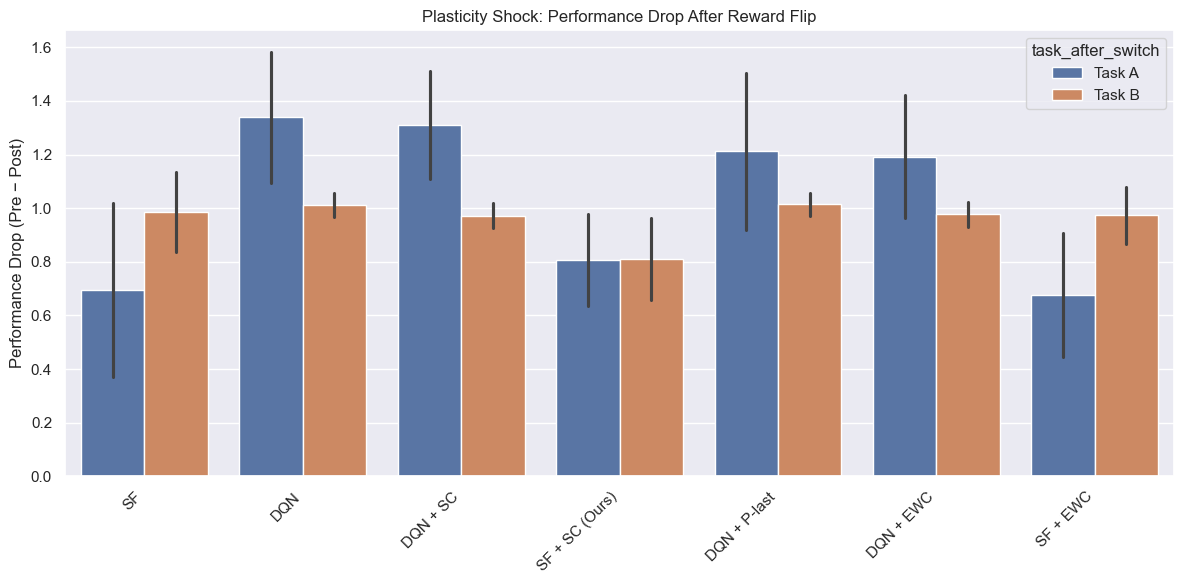

In [299]:
AGENT_ORDER = [
    "SF",
    "DQN",
    "DQN + SC",
    "SF + SC (Ours)",
    "DQN + P-last",
    "DQN + EWC",
    "SF + EWC",
]

TASK_LABELS = {0: "Task A", 1: "Task B"}

df = drop_all.copy()
# Optional: pretty task names on hue
if "task_after_switch" in df.columns:
    df["task_after_switch"] = df["task_after_switch"].map(TASK_LABELS).fillna(df["task_after_switch"])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x="agent_name",
    y="delta",
    hue="task_after_switch",
    order=AGENT_ORDER,
    errorbar="sd",
)
plt.xticks(rotation=45, ha="right")
plt.title("Plasticity Shock: Performance Drop After Reward Flip")
plt.ylabel("Performance Drop (Pre − Post)")
plt.xlabel("")
plt.tight_layout()
plt.show()

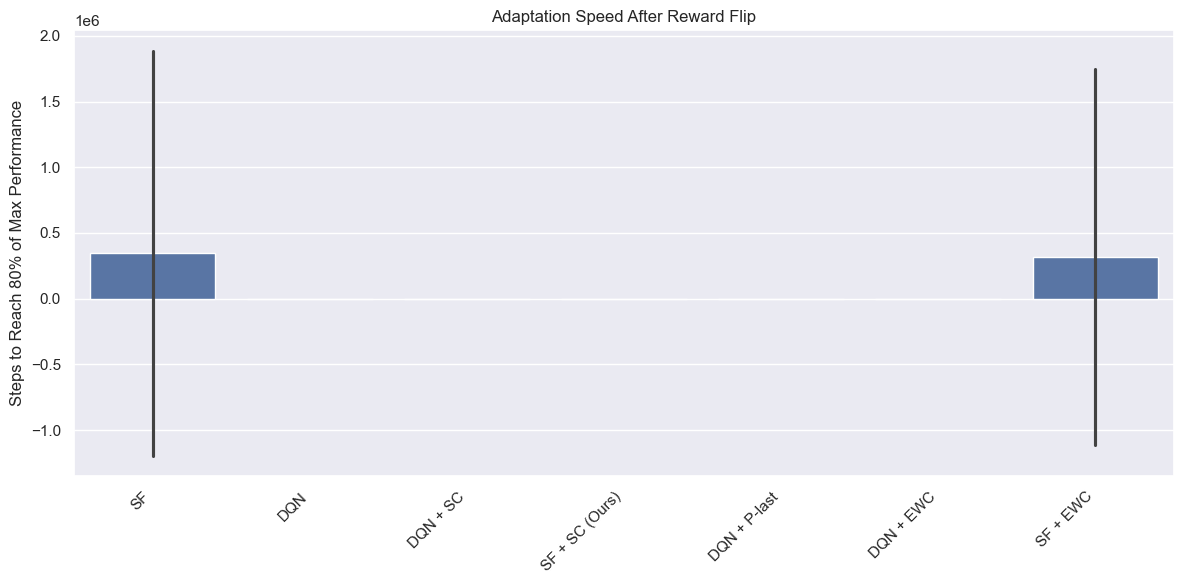

In [300]:
df = adapt_all.copy()
if "task_after_switch" in df.columns:
    df["task_after_switch"] = df["task_after_switch"].map(TASK_LABELS).fillna(df["task_after_switch"])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x="agent_name",
    y="adapt_steps",
    order=AGENT_ORDER,
    errorbar="sd",
)
plt.xticks(rotation=45, ha="right")
plt.title("Adaptation Speed After Reward Flip")
plt.ylabel("Steps to Reach 80% of Max Performance")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [301]:
print(adapt_all)

     switch_step  task_after_switch  P_max  target  adapt_steps  \
0        5000000                  0      1     0.8          0.0   
1       10000000                  1      1     0.8          0.0   
2       15000000                  0      1     0.8          0.0   
3       20000000                  1      1     0.8          0.0   
4        5000000                  0      1     0.8          0.0   
..           ...                ...    ...     ...          ...   
183     20000000                  1      1     0.8          0.0   
184      5000000                  0      1     0.8    5500000.0   
185     10000000                  1      1     0.8          0.0   
186     15000000                  0      1     0.8          0.0   
187     20000000                  1      1     0.8          0.0   

                     agent_name  
0                           DQN  
1                           DQN  
2                           DQN  
3                           DQN  
4                        

In [302]:
S = 5_000_000   # switch step
task_after = 0  # or use get_task_at_step if you prefer
alpha = 0.8

agent = "SF + SC (Ours)"  # or whichever
df_agent = runs_df[runs_df["agent_name"] == agent].copy()

p_max = (
    df_agent
    .groupby("train/task_clean")["eval/episode_return"]
    .max()
)
print(p_max)

P_max_task = p_max[task_after]
target = alpha * P_max_task

print("P_max:", P_max_task)
print("target:", target)

df_debug = df_agent[
    (df_agent["eval/steps"] >= S - 200_000) &
    (df_agent["eval/steps"] <= S + 200_000)
][["eval/steps", "train/task_clean", "eval/episode_return"]]

print(df_debug)


train/task_clean
0    1
1    1
Name: eval/episode_return, dtype: object
P_max: 1
target: 0.8
     eval/steps  train/task_clean eval/episode_return
3047  4800000.0                 0            0.987342
3048  4900000.0                 0                   1
3049  5000000.0                 0                   1
3050  5100000.0                 1                 0.2
3051  5200000.0                 1                -0.2
3247  4800000.0                 0            0.922078
3248  4900000.0                 0                   1
3249  5000000.0                 0            0.962617
3250  5100000.0                 1           -0.142857
3251  5200000.0                 1                 0.2
3447  4800000.0                 0            0.968254
3448  4900000.0                 0                   1
3449  5000000.0                 0                   1
3450  5100000.0                 1                   0
3451  5200000.0                 1            0.142857
3647  4800000.0                 0          

In [303]:
print(df)

     switch_step task_after_switch  P_max  target  adapt_steps  \
0        5000000            Task A      1     0.8          0.0   
1       10000000            Task B      1     0.8          0.0   
2       15000000            Task A      1     0.8          0.0   
3       20000000            Task B      1     0.8          0.0   
4        5000000            Task A      1     0.8          0.0   
..           ...               ...    ...     ...          ...   
183     20000000            Task B      1     0.8          0.0   
184      5000000            Task A      1     0.8    5500000.0   
185     10000000            Task B      1     0.8          0.0   
186     15000000            Task A      1     0.8          0.0   
187     20000000            Task B      1     0.8          0.0   

                     agent_name  
0                           DQN  
1                           DQN  
2                           DQN  
3                           DQN  
4                           DQN  
.. 

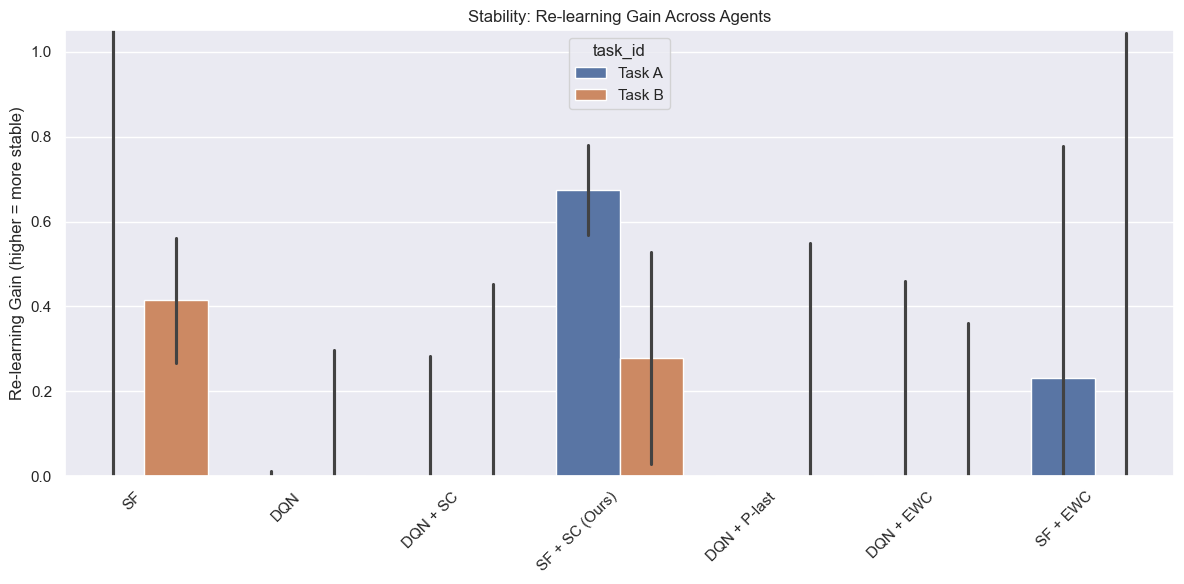

In [304]:
df = relearn_all.copy()
if "task_id" in df.columns:
    df["task_id"] = df["task_id"].map(TASK_LABELS).fillna(df["task_id"])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x="agent_name",
    y="RelearnGain",
    hue="task_id",
    order=AGENT_ORDER,
    errorbar="sd",
)
plt.xticks(rotation=45, ha="right")
plt.title("Stability: Re-learning Gain Across Agents")
plt.ylabel("Re-learning Gain (higher = more stable)")
plt.xlabel("")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

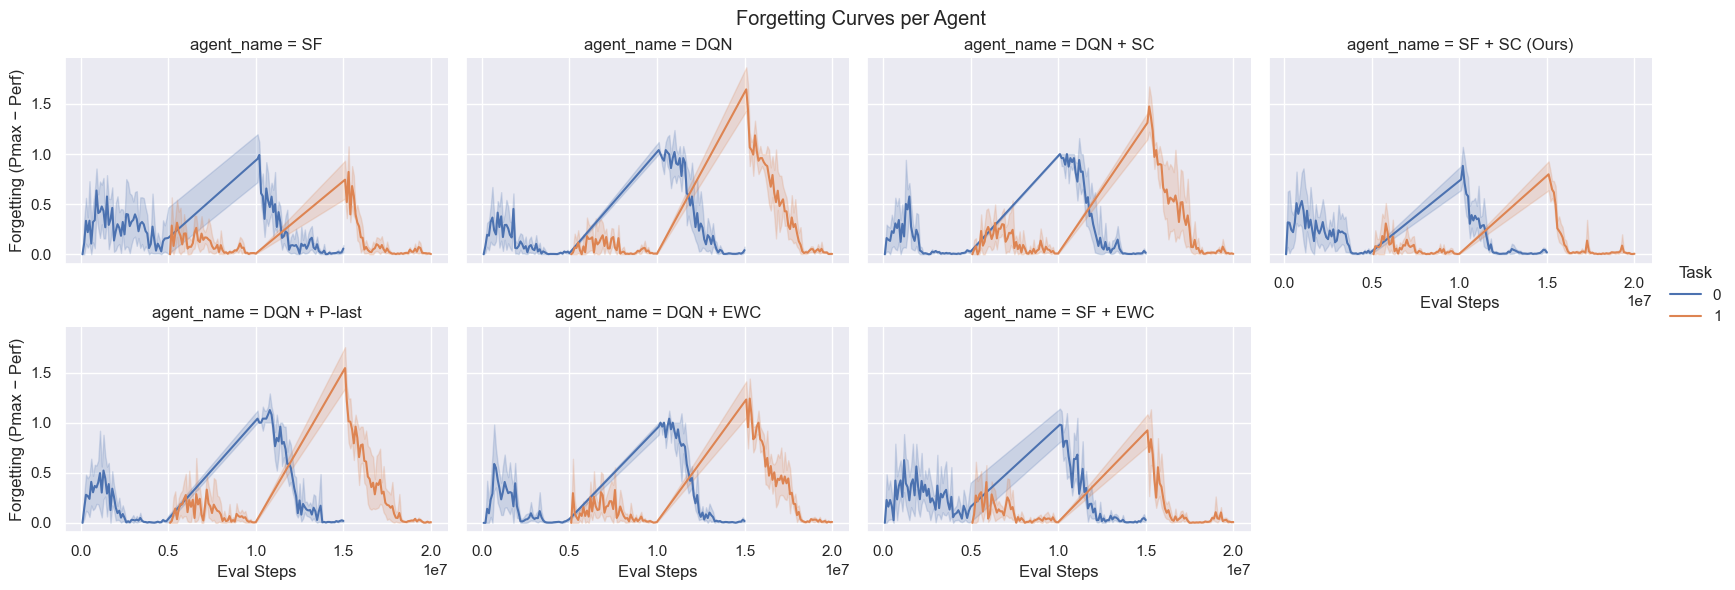

In [305]:
df = forget_all.copy()

g = sns.FacetGrid(
    df,
    col="agent_name",
    col_wrap=4,
    hue="train/task_clean",
    col_order=AGENT_ORDER,
    sharey=True,
    height=3.0,
    aspect=1.4,
)
g.map(sns.lineplot, "eval/steps", "forgetting")
g.add_legend(title="Task")
g.set_axis_labels("Eval Steps", "Forgetting (Pmax − Perf)")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Forgetting Curves per Agent")
plt.show()

In [306]:
print(df)

      eval/steps  train/task_clean      perf  P_max_so_far  forgetting  \
0       100000.0                 0  0.333333      0.333333    0.000000   
1       200000.0                 0  0.500000      0.500000    0.000000   
2       300000.0                 0  0.333333      0.500000    0.166667   
3       400000.0                 0  0.200000      0.500000    0.300000   
4       500000.0                 0 -0.062500      0.500000    0.562500   
...          ...               ...       ...           ...         ...   
9395  19600000.0                 1  1.000000      1.000000    0.000000   
9396  19700000.0                 1  1.000000      1.000000    0.000000   
9397  19800000.0                 1  0.989950      1.000000    0.010050   
9398  19900000.0                 1  0.995604      1.000000    0.004396   
9399  20000000.0                 1  0.991453      1.000000    0.008547   

                      agent_name  
0                            DQN  
1                            DQN  
2     